<a href="https://colab.research.google.com/github/SeulGiPark-KISTI/-study/blob/main/09_unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Chapter 9 – Unsupervised Learning**

_This notebook contains all the sample code and solutions to the exercises in chapter 9._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/09_unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/09_unsupervised_learning.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [2]:
import sys

assert sys.version_info >= (3, 7) # Python 버전 확인 (3.7 이상 권장)

It also requires Scikit-Learn ≥ 1.0.1:

In [3]:
from packaging import version  # 버전 비교를 위한 유틸리티
import sklearn
# Scikit-Learn 버전이 1.0.1 이상인지 확인
assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

As we did in previous chapters, let's define the default font sizes to make the figures prettier:

In [4]:
import matplotlib.pyplot as plt
# 전역 폰트 및 그래프 스타일 설정, 가독성 향상 및 일관성 확보 목적
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

And let's create the `images/unsupervised_learning` folder (if it doesn't already exist), and define the `save_fig()` function which is used through this notebook to save the figures in high-res for the book:

In [5]:
from pathlib import Path # 파일 경로 처리를 위한 모듈 (운영체제 간 호환성 우수)

# 이미지 저장 경로 생성: ./images/unsupervised_learning, Path 객체는 문자열보다 안전하고 유연한 경로 처리 가능
# exist_ok=True: 이미 디렉토리가 존재해도 에러 발생하지 않음
IMAGES_PATH = Path() / "images" / "unsupervised_learning"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

# 시각화 결과 저장 함수 정의
def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

First, let's import a few common modules, ensure MatplotLib plots figures inline and prepare a function to save the figures.

# Clustering

**Introduction – Classification _vs_ Clustering**

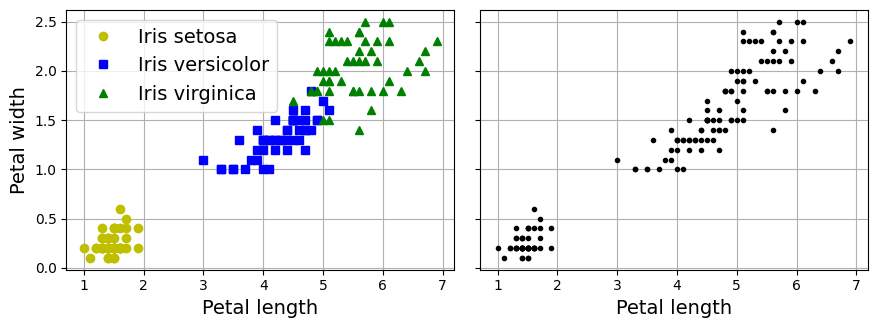

In [6]:
# extra code – this cell generates and saves Figure 9–1

import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

data = load_iris()  # Iris 데이터셋 로드
X = data.data       # X: 특성값 (4차원)
y = data.target     # y: 레이블 (0=Setosa, 1=Versicolor, 2=Virginica)
data.target_names

# Classification vs Clustering 비교 시각화
plt.figure(figsize=(9, 3.5))

# 왼쪽 그림: supervised classification (라벨 있음)
plt.subplot(121)
plt.plot(X[y==0, 2], X[y==0, 3], "yo", label="Iris setosa")
plt.plot(X[y==1, 2], X[y==1, 3], "bs", label="Iris versicolor")
plt.plot(X[y==2, 2], X[y==2, 3], "g^", label="Iris virginica")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.grid()
plt.legend()

# 오른쪽 그림: unsupervised clustering (라벨 없음)
plt.subplot(122)
plt.scatter(X[:, 2], X[:, 3], c="k", marker=".")
plt.xlabel("Petal length")
plt.tick_params(labelleft=False)
plt.gca().set_axisbelow(True)
plt.grid()

save_fig("classification_vs_clustering_plot")
plt.show()

**Note**: the next cell shows how a Gaussian mixture model (explained later in this chapter) can actually separate these clusters pretty well using all 4 features: petal length & width, and sepal length & width. This code maps each cluster to a class. Instead of hard coding the mapping, the code picks the most common class for each cluster using the `scipy.stats.mode()` function:

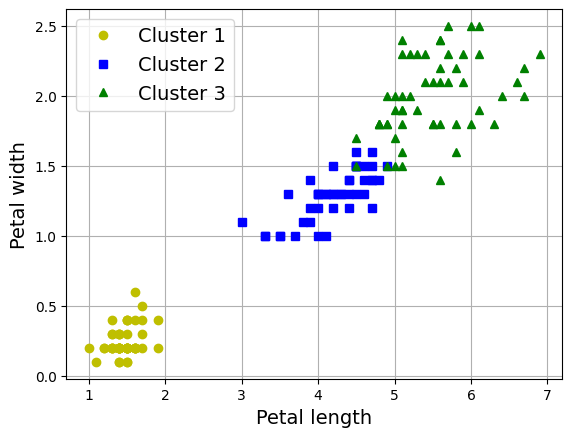

In [7]:
# extra code

import numpy as np
from scipy import stats
from sklearn.mixture import GaussianMixture

# Gaussian Mixture Model (GMM)을 사용한 클러스터링
# n_components=3: 클러스터 수 = 클래스 수와 동일하게 설정
# predict(): 각 샘플이 속한 클러스터 ID 반환 (0, 1, 2)
y_pred = GaussianMixture(n_components=3, random_state=42).fit(X).predict(X)

# 각 클러스터 ID를 실제 클래스 ID로 매핑
# 동일 클래스의 샘플들이 속한 클러스터의 '최빈값'을 기준으로 매핑
mapping = {}
for class_id in np.unique(y): # class_id: 0, 1, 2
    mode, _ = stats.mode(y_pred[y==class_id])
    mapping[mode] = class_id  # 클러스터 ID → 클래스 ID

# 클러스터 결과를 실제 클래스처럼 재매핑
y_pred = np.array([mapping[cluster_id] for cluster_id in y_pred])

plt.plot(X[y_pred==0, 2], X[y_pred==0, 3], "yo", label="Cluster 1")
plt.plot(X[y_pred==1, 2], X[y_pred==1, 3], "bs", label="Cluster 2")
plt.plot(X[y_pred==2, 2], X[y_pred==2, 3], "g^", label="Cluster 3")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.grid()
plt.show()

What's the ratio of iris plants we assigned to the right cluster?

In [8]:
# 클러스터링 정확도
(y_pred==y).sum() / len(y_pred)

np.float64(0.9666666666666667)

## K-Means

**Fit and predict**

Let's train a K-Means clusterer on a dataset if blobs. It will try to find each blob's center and assign each instance to the closest blob:

In [9]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# extra code – the exact arguments of make_blobs() are not important
# 블롭 중심 및 각 클러스터의 표준편차 정의, 중심 좌표 5개 → 클러스터 수 5개
# 표준편차가 다름: 각 블롭의 퍼짐 정도를 지정

blob_centers = np.array([[ 0.2,  2.3], [-1.5 ,  2.3], [-2.8,  1.8],
                         [-2.8,  2.8], [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])

# 인공 데이터 생성, 2차원 평면에 퍼진 5개의 클러스터 샘플 2,000개 생성
# X: 입력 좌표 (shape: [2000, 2])
# y: 실제 클러스터 레이블 (검증용, 학습에는 사용 안 함)
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std,
                  random_state=7)

k = 5
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
y_pred = kmeans.fit_predict(X)

Note: Throughout this notebook, when `n_init` was not set when creating a `KMeans` estimator, I explicitly set it to `n_init=10` to avoid a warning about the fact that the default value for this hyperparameter will change from 10 to `"auto"` in Scikit-Learn 1.4.

Now let's plot them:

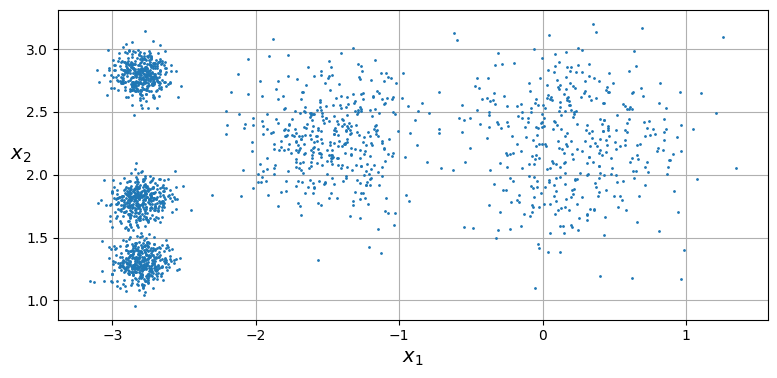

In [10]:
# extra code – this cell generates and saves Figure 9–2

# 클러스터 데이터를 시각화하는 함수
def plot_clusters(X, y=None):
# 점 색깔은 y에 따라 (없으면 모두 동일색)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$") # x축 라벨
    plt.ylabel("$x_2$", rotation=0) # y축 라벨 (회전 없이)

# Figure 9–2: 생성된 블롭 데이터 시각화
plt.figure(figsize=(8, 4))  # 가로로 넓은 그림
plot_clusters(X)  # 군집 색 없이 전체 구조 시각화
plt.gca().set_axisbelow(True) # 격자를 데이터 뒤로 배치
plt.grid()  # 격자 표시
save_fig("blobs_plot")
plt.show()

Each instance was assigned to one of the 5 clusters:

In [11]:
y_pred

array([0, 0, 4, ..., 3, 1, 0], dtype=int32)

In [12]:
y_pred is kmeans.labels_

True

And the following 5 _centroids_ (i.e., cluster centers) were estimated:

In [13]:
kmeans.cluster_centers_

array([[-2.80214068,  1.55162671],
       [ 0.08703534,  2.58438091],
       [-1.46869323,  2.28214236],
       [-2.79290307,  2.79641063],
       [ 0.31332823,  1.96822352]])

Note that the `KMeans` instance preserves the labels of the instances it was trained on. Somewhat confusingly, in this context, the _label_ of an instance is the index of the cluster that instance gets assigned to (they are not targets, they are predictions):

In [14]:
kmeans.labels_

array([0, 0, 4, ..., 3, 1, 0], dtype=int32)

Of course, we can predict the labels of new instances:

In [15]:
import numpy as np
# 새로운 샘플 포인트 4개 정의 (2차원 좌표)
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
# 각 샘플이 할당될 클러스터 ID 예측
# kmeans는 앞서 학습된 모델이어야 함 (kmeans.fit(...) 필요)
kmeans.predict(X_new)

array([4, 4, 3, 3], dtype=int32)

**Decision Boundaries**

Let's plot the model's decision boundaries. This gives us a _Voronoi diagram_:

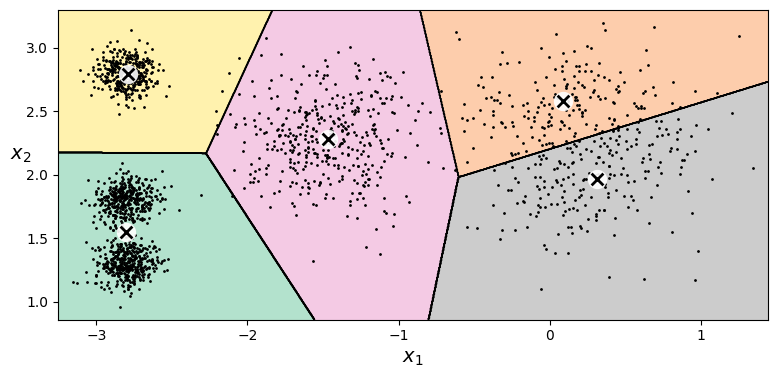

In [16]:
# extra code – this cell generates and saves Figure 9–3
# KMeans 클러스터링의 결정 경계(Decision Boundaries)와 중심점을 시각화

# 데이터 포인트를 작은 검은 점으로 시각화
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    # 클러스터 중심 표시: 흰 동그라미 + 검정 X자
    # weights가 주어지면, 중요도 낮은 중심은 제외 (예: GMM에서 활용)
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    # 중심 원
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    # 중심 교차 표시
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    # 결정 경계 시각화 함수
    # 1. (x1, x2) meshgrid 생성
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    # 2. 모든 점에 대해 클러스터 예측
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 3. 배경 색깔 채우기 (Pastel 색)
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    # 4. 경계선 그리기
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    # 5. 데이터와 중심 시각화
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)
    # 6. 라벨 표시 여부
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
save_fig("voronoi_plot")
plt.show()

Not bad! Some of the instances near the edges were probably assigned to the wrong cluster, but overall it looks pretty good.

**Hard Clustering _vs_ Soft Clustering**

Rather than arbitrarily choosing the closest cluster for each instance, which is called _hard clustering_, it might be better to measure the distance of each instance to all 5 centroids. This is what the `transform()` method does:

KMeans.transform(X_new) 메서드: hard clustering 대신 soft한 거리 기반 클러스터링 정보를 제공하며, 이를 통해 각 샘플이 각 클러스터 중심과 얼마나 가까운지를 수치로 확인

In [17]:
kmeans.transform(X_new).round(2)

array([[2.84, 0.59, 1.5 , 2.9 , 0.31],
       [5.82, 2.97, 4.48, 5.85, 2.69],
       [1.46, 3.11, 1.69, 0.29, 3.47],
       [0.97, 3.09, 1.55, 0.36, 3.36]])

You can verify that this is indeed the Euclidian distance between each instance and each centroid:

In [18]:
# extra code transform()이 유클리디안 거리 기반임을 확인.
np.linalg.norm(np.tile(X_new, (1, k)).reshape(-1, k, 2)
               - kmeans.cluster_centers_, axis=2).round(2)

array([[2.84, 0.59, 1.5 , 2.9 , 0.31],
       [5.82, 2.97, 4.48, 5.85, 2.69],
       [1.46, 3.11, 1.69, 0.29, 3.47],
       [0.97, 3.09, 1.55, 0.36, 3.36]])

### The K-Means Algorithm

The K-Means algorithm is one of the fastest clustering algorithms, and also one of the simplest:
* First initialize $k$ centroids randomly: e.g., $k$ distinct instances are chosen randomly from the dataset and the centroids are placed at their locations.
* Repeat until convergence (i.e., until the centroids stop moving):
    * Assign each instance to the closest centroid.
    * Update the centroids to be the mean of the instances that are assigned to them.

The `KMeans` class uses an optimized initialization technique by default. To get the original K-Means algorithm (for educational purposes only), you must set `init="random"` and `n_init=1`. More on this later in this chapter.

Let's run the K-Means algorithm for 1, 2 and 3 iterations, to see how the centroids move around:

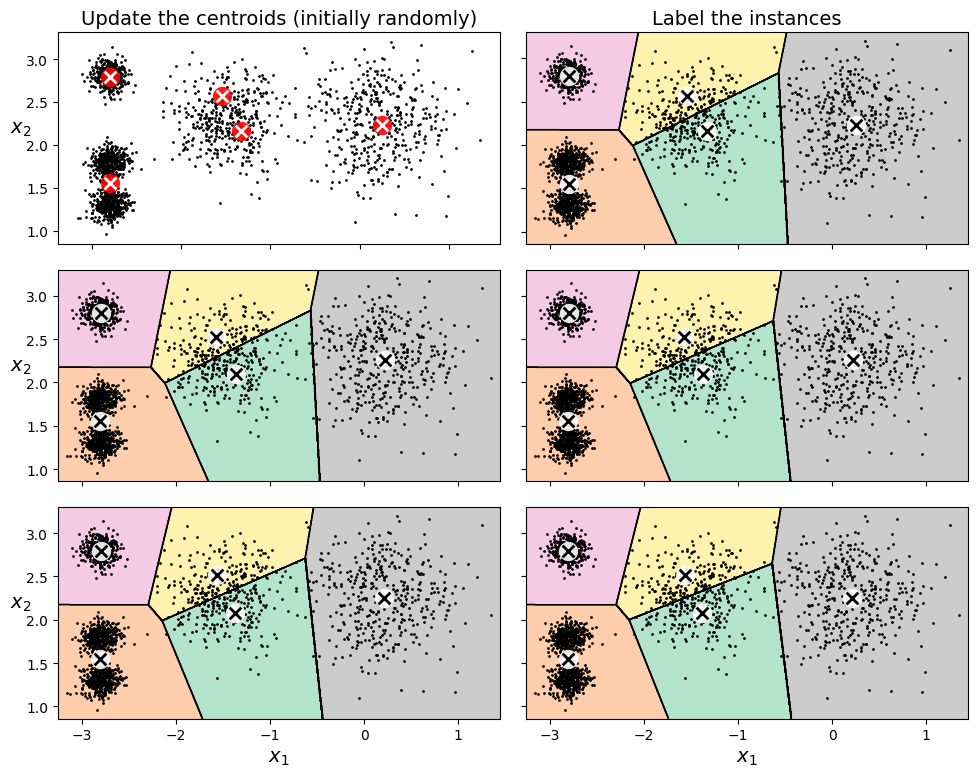

In [19]:
# extra code – this cell generates and saves Figure 9–4
# 각 반복 단계별 KMeans 모델 생성 (iteration 제한)
kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=1,
                      random_state=5)
kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=2,
                      random_state=5)
kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=3,
                      random_state=5)
# 각 단계별 클러스터링 실행
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)")

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False,
                         show_ylabels=False)
plt.title("Label the instances")

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False,
                         show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False,
                         show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

save_fig("kmeans_algorithm_plot")
plt.show()

**K-Means Variability**

In the original K-Means algorithm, the centroids are just initialized randomly, and the algorithm simply runs a single iteration to gradually improve the centroids, as we saw above.

However, one major problem with this approach is that if you run K-Means multiple times (or with different random seeds), it can converge to very different solutions, as you can see below:

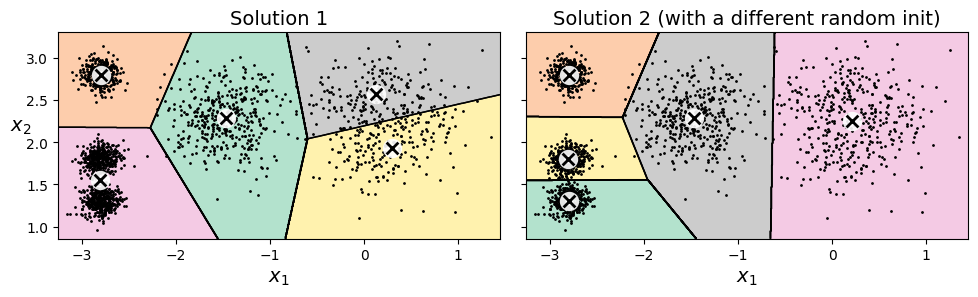

In [20]:
# extra code – this cell generates and saves Figure 9–5
#1. 시각화 함수 정의
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None,
                              title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2)
#2. 서로 다른 초기화로 두 개의 모델 학습
kmeans_rnd_init1 = KMeans(n_clusters=5, init="random", n_init=1, random_state=2)
kmeans_rnd_init2 = KMeans(n_clusters=5, init="random", n_init=1, random_state=9)
#3. 두 결과를 나란히 시각화
plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,
                          "Solution 1",
                          "Solution 2 (with a different random init)")

save_fig("kmeans_variability_plot")
plt.show()

In [21]:
# 좋은 초기 중심 좌표 수동 설정 (5개 클러스터용)
good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])
# KMeans 객체 생성: 클러스터 수: 5
# init=good_init → 수동 중심 초기화, n_init=1 → 한 번만 실행 (여러 번 초기화 없음)
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1, random_state=42)
kmeans.fit(X)

KMeans(init=array([[-3,  3],
       [-3,  2],
       [-3,  1],
       [-1,  2],
       [ 0,  2]]),
       n_clusters=5, n_init=1, random_state=42)

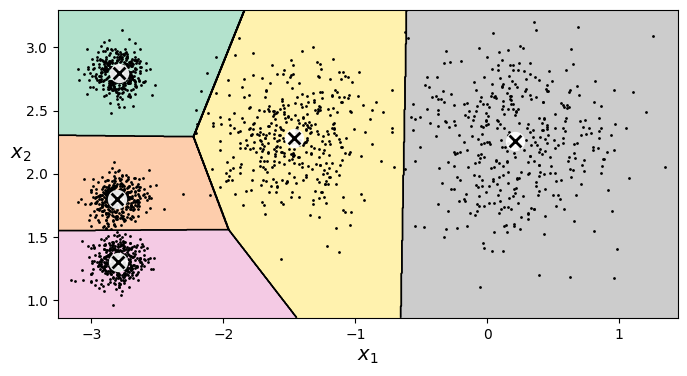

In [22]:
# extra code
plt.figure(figsize=(8, 4))
# 앞서 학습된 KMeans 객체(kmeans)의 클러스터 경계를 시각화
# 각 샘플의 소속 클러스터 영역(Voronoi diagram 유사) 표시
plot_decision_boundaries(kmeans, X)

### Inertia

To select the best model, we will need a way to evaluate a K-Mean model's performance. Unfortunately, clustering is an unsupervised task, so we do not have the targets. But at least we can measure the distance between each instance and its centroid. This is the idea behind the _inertia_ metric:

In [23]:
# 군집 내 거리 제곱합: 작을수록 좋음
#	샘플들이 자신의 클러스터 중심에 가깝게 모여 있음
kmeans.inertia_

211.59853725816828

In [24]:
kmeans_rnd_init1.inertia_  # extra code

219.58201503602285

In [25]:
kmeans_rnd_init2.inertia_  # extra code

211.59853725816828

As you can easily verify, inertia is the sum of the squared distances between each training instance and its closest centroid:

In [26]:
# extra code
X_dist = kmeans.transform(X)
(X_dist[np.arange(len(X_dist)), kmeans.labels_] ** 2).sum()

np.float64(211.59853725816882)

The `score()` method returns the negative inertia. Why negative? Well, it is because a predictor's `score()` method must always respect the "_greater is better_" rule.

In [27]:
# 군집 내 거리 제곱합: 작을수록 좋음
# -inertia_	클수록 좋음 (Scikit-Learn 규칙 충족)
kmeans.score(X)

-211.59853725816828

### Multiple Initializations

So one approach to solve the variability issue is to simply run the K-Means algorithm multiple times with different random initializations, and select the solution that minimizes the inertia.

When you set the `n_init` hyperparameter, Scikit-Learn runs the original algorithm `n_init` times, and selects the solution that minimizes the inertia. By default, Scikit-Learn sets `n_init=10`.

In [28]:
# extra code
# 무작위 중심 초기화 방식으로 KMeans를 실행하되,
# 10번 초기화를 반복하여 최적의 결과(최소 inertia)를 선택
kmeans_rnd_10_inits = KMeans(n_clusters=5, init="random", n_init=10,
                             random_state=2)
# 서로 다른 초기화 10회 수행 후 최적 결과 선택
kmeans_rnd_10_inits.fit(X)

KMeans(init='random', n_clusters=5, n_init=10, random_state=2)

As you can see, we end up with the initial model, which is certainly the optimal K-Means solution (at least in terms of inertia, and assuming $k=5$).

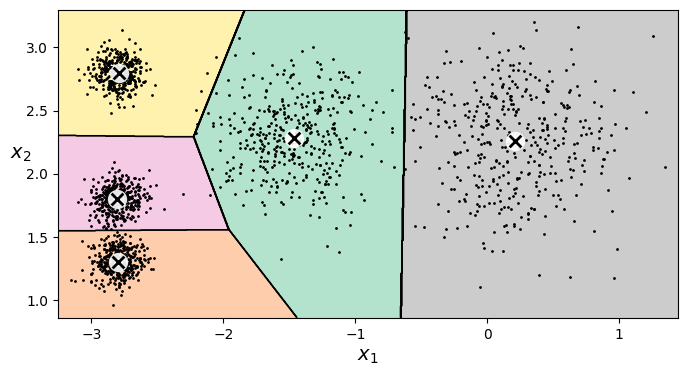

In [29]:
# extra code
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans_rnd_10_inits, X)
plt.show()

In [30]:
# 각 샘플이 자신의 클러스터 중심으로부터 평균적으로 꽤 가까이 위치
kmeans_rnd_10_inits.inertia_

211.59853725816828

### Centroid initialization methods

Instead of initializing the centroids entirely randomly, it is preferable to initialize them using the following algorithm, proposed in a [2006 paper](https://goo.gl/eNUPw6) by David Arthur and Sergei Vassilvitskii:
* Take one centroid $c_1$, chosen uniformly at random from the dataset.
* Take a new center $c_i$, choosing an instance $\mathbf{x}_i$ with probability: $D(\mathbf{x}_i)^2$ / $\sum\limits_{j=1}^{m}{D(\mathbf{x}_j)}^2$ where $D(\mathbf{x}_i)$ is the distance between the instance $\mathbf{x}_i$ and the closest centroid that was already chosen. This probability distribution ensures that instances that are further away from already chosen centroids are much more likely be selected as centroids.
* Repeat the previous step until all $k$ centroids have been chosen.

The rest of the K-Means++ algorithm is just regular K-Means. With this initialization, the K-Means algorithm is much less likely to converge to a suboptimal solution, so it is possible to reduce `n_init` considerably. Most of the time, this largely compensates for the additional complexity of the initialization process.

To set the initialization to K-Means++, simply set `init="k-means++"` (this is actually the default):

### Accelerated K-Means

The K-Means algorithm can sometimes be accelerated by avoiding many unnecessary distance calculations: this is achieved by exploiting the triangle inequality (given three points A, B and C, the distance AC is always such that AC ≤ AB + BC) and by keeping track of lower and upper bounds for distances between instances and centroids (see this [2003 paper](https://www.aaai.org/Papers/ICML/2003/ICML03-022.pdf) by Charles Elkan for more details).

For Elkan's variant of K-Means, use `algorithm="elkan"`. For regular KMeans, use `algorithm="full"`. The default is `"auto"`, which uses the full algorithm since Scikit-Learn 1.1 (it used Elkan's algorithm before that).

### Mini-Batch K-Means

Scikit-Learn also implements a variant of the K-Means algorithm that supports mini-batches (see [this paper](http://www.eecs.tufts.edu/~dsculley/papers/fastkmeans.pdf)):

In [31]:
from sklearn.cluster import MiniBatchKMeans
# K-Means 초기화 및 변형 알고리즘
# k-means++ 초기화 사용 (기본값)
minibatch_kmeans = MiniBatchKMeans(n_clusters=5, n_init=3, random_state=42)
minibatch_kmeans.fit(X)

MiniBatchKMeans(n_clusters=5, n_init=3, random_state=42)

Note: Throughout this notebook, when `n_init` was not set when creating a `MiniBatchKMeans` estimator, I explicitly set it to `n_init=3` to avoid a warning about the fact that the default value for this hyperparameter will change from 3 to `"auto"` in Scikit-Learn 1.4.

In [32]:
minibatch_kmeans.inertia_

211.65899374574317

**Using `MiniBatchKMeans` along with `memmap`** (not in the book)

If the dataset does not fit in memory, the simplest option is to use the `memmap` class, just like we did for incremental PCA in the previous chapter. First let's load MNIST:

# MiniBatchKMeans와 numpy.memmap을 함께 사용하는 것?
# 대용량 데이터셋(예: MNIST) 을 메모리에 모두 적재하지 않고도 클러스터링 가능

In [33]:
from sklearn.datasets import fetch_openml
# MNIST 데이터셋을 numpy 배열로 로드
# 'mnist_784': 28x28 이미지(784차원)와 레이블(0~9)
# as_frame=False: pandas DataFrame이 아닌 numpy 배열로 반환
# parser="auto": 버전에 따라 자동 파서 사용
mnist = fetch_openml('mnist_784', as_frame=False, parser="auto")

Let's split the dataset:

In [34]:
# mnist.data.shape (70000, 784)
# mnist.target.shape (70000,)
# mnist.data[60000:].shape (10000, 784)

X_train, y_train = mnist.data[:60000], mnist.target[:60000]    # 60000개
X_test, y_test = mnist.data[60000:], mnist.target[60000:]      # 10000


Next, let's write the training set to a `memmap`:

In [35]:
# X_train 데이터를 디스크에 메모리 매핑

filename = "my_mnist.mmap"
X_memmap = np.memmap(filename, dtype='float32', mode='write',
                     shape=X_train.shape)
X_memmap[:] = X_train
X_memmap.flush()

In [36]:
from sklearn.cluster import MiniBatchKMeans

# MiniBatchKMeans 클러스터링 모델 정의 및 학습
# 10개의 클러스터 (MNIST는 0~9 숫자 10개)
# 한 번에 10개 샘플씩 미니배치 학습
# 초기 중심점 설정을 3번 반복하여 가장 좋은 결과 선택
minibatch_kmeans = MiniBatchKMeans(n_clusters=10, batch_size=10,
                                   n_init=3, random_state=42)
minibatch_kmeans.fit(X_memmap)

MiniBatchKMeans(batch_size=10, n_clusters=10, n_init=3, random_state=42)

Let's plot the inertia ratio and the training time ratio between Mini-batch K-Means and regular K-Means:

100/100

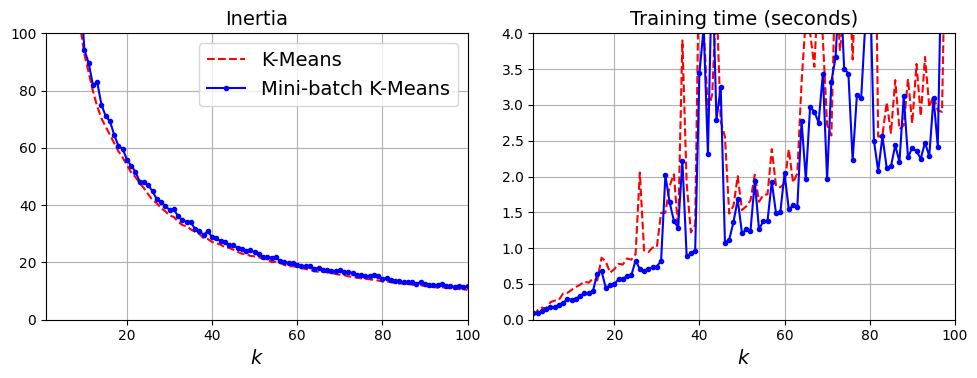

In [37]:
# extra code – this cell generates and saves Figure 9–6
# 목적: KMeans vs MiniBatchKMeans 비교 (inertia와 학습 시간 측정)

from timeit import timeit

max_k = 100
# 각 k에 대해 [KMeans 시간, MiniBatchKMeans 시간]
times = np.empty((max_k, 2))
# 각 k에 대해 [KMeans inertia, MiniBatchKMeans inertia]
inertias = np.empty((max_k, 2))

# k=1부터 max_k=100까지 클러스터 수를 늘려가며 비교
for k in range(1, max_k + 1):
    kmeans_ = KMeans(n_clusters=k, algorithm="lloyd", n_init=10, random_state=42)
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, n_init=10, random_state=42)
    print(f"\r{k}/{max_k}", end="")  # \r returns to the start of line

    # 각각의 모델 학습에 걸리는 시간 측정 (10번 반복 평균)
    times[k - 1, 0] = timeit("kmeans_.fit(X)", number=10, globals=globals())
    times[k - 1, 1] = timeit("minibatch_kmeans.fit(X)", number=10,
                             globals=globals())

    # 학습된 모델의 inertia 저장 (클러스터링 성능 지표)
    inertias[k - 1, 0] = kmeans_.inertia_
    inertias[k - 1, 1] = minibatch_kmeans.inertia_

plt.figure(figsize=(10, 4))

# Inertia 비교
plt.subplot(121)
plt.plot(range(1, max_k + 1), inertias[:, 0], "r--", label="K-Means")
plt.plot(range(1, max_k + 1), inertias[:, 1], "b.-", label="Mini-batch K-Means")
plt.xlabel("$k$")
plt.title("Inertia")
plt.legend()
plt.axis([1, max_k, 0, 100])
plt.grid()

# 학습 시간 비교
plt.subplot(122)
plt.plot(range(1, max_k + 1), times[:, 0], "r--", label="K-Means")
plt.plot(range(1, max_k + 1), times[:, 1], "b.-", label="Mini-batch K-Means")
plt.xlabel("$k$")
plt.title("Training time (seconds)")
plt.axis([1, max_k, 0, 4])
plt.grid()

save_fig("minibatch_kmeans_vs_kmeans_plot")
plt.show()

### Finding the optimal number of clusters

What if the number of clusters was set to a lower or greater value than 5?

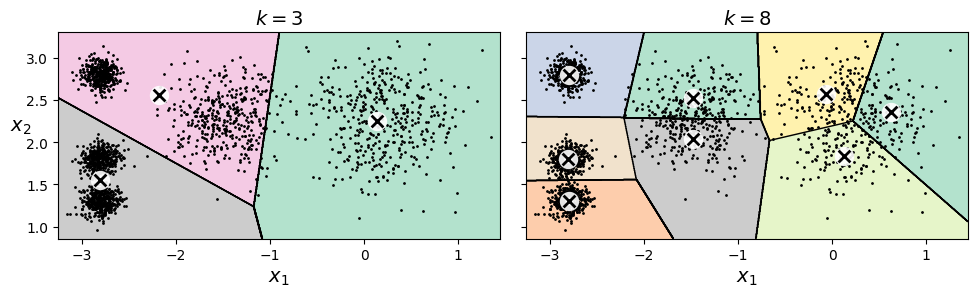

In [38]:
# extra code – this cell generates and saves Figure 9–7
# 클러스터 개수를 너무 작게(k=3) 또는 너무 많게(k=8) 설정했을 때의 결과 시각화

# 클러스터 수가 부족한 경우
kmeans_k3 = KMeans(n_clusters=3, n_init=10, random_state=42)
# 클러스터 수가 과한 경우
kmeans_k8 = KMeans(n_clusters=8, n_init=10, random_state=42)

# 두 모델 결과 시각화 비교
plot_clusterer_comparison(kmeans_k3, kmeans_k8, X, "$k=3$", "$k=8$")
save_fig("bad_n_clusters_plot")
plt.show()

Ouch, these two models don't look great. What about their inertias?

In [39]:
kmeans_k3.inertia_

653.2167190021554

In [40]:
kmeans_k8.inertia_

119.22484592677135

No, we cannot simply take the value of $k$ that minimizes the inertia, since it keeps getting lower as we increase $k$. Indeed, the more clusters there are, the closer each instance will be to its closest centroid, and therefore the lower the inertia will be. However, we can plot the inertia as a function of $k$ and analyze the resulting curve:

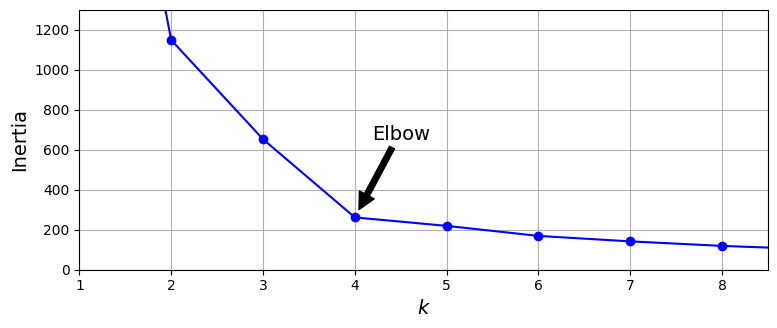

In [41]:
# extra code – this cell generates and saves Figure 9–8
# 엘보우 방법 (Elbow method): inertia 곡선에서 굴곡점 찾기

# k=1부터 9까지 각 클러스터 수에 대해 KMeans 모델 학습
kmeans_per_k = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
                for k in range(1, 10)]

# 각 k에 해당하는 inertia(클러스터 내부 거리 제곱합) 저장
inertias = [model.inertia_ for model in kmeans_per_k]

# inertia Vs. k
plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.annotate("", xy=(4, inertias[3]), xytext=(4.45, 650),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.text(4.5, 650, "Elbow", horizontalalignment="center")
plt.axis([1, 8.5, 0, 1300])
plt.grid()
save_fig("inertia_vs_k_plot")
plt.show()

As you can see, there is an elbow at $k=4$, which means that less clusters than that would be bad, and more clusters would not help much and might cut clusters in half. So $k=4$ is a pretty good choice. Of course in this example it is not perfect since it means that the two blobs in the lower left will be considered as just a single cluster, but it's a pretty good clustering nonetheless.

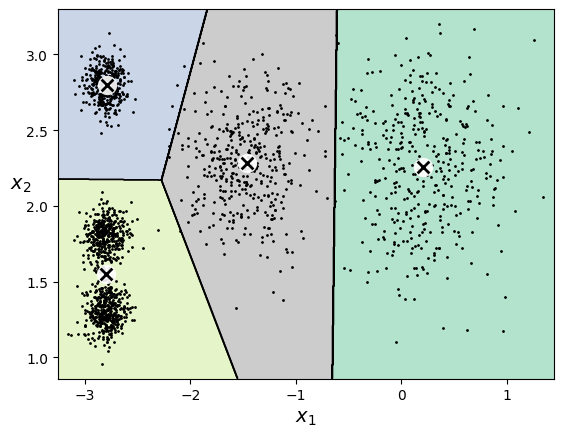

In [42]:
# extra code
# 엘보우 방법에서 선택된 k=4 모델의 결정 경계 시각화
plot_decision_boundaries(kmeans_per_k[4 - 1], X)
plt.show()

Another approach is to look at the _silhouette score_, which is the mean _silhouette coefficient_ over all the instances. An instance's silhouette coefficient is equal to (_b_ - _a_) / max(_a_, _b_) where _a_ is the mean distance to the other instances in the same cluster (it is the _mean intra-cluster distance_), and _b_ is the _mean nearest-cluster distance_, that is the mean distance to the instances of the next closest cluster (defined as the one that minimizes _b_, excluding the instance's own cluster). The silhouette coefficient can vary between -1 and +1: a coefficient close to +1 means that the instance is well inside its own cluster and far from other clusters, while a coefficient close to 0 means that it is close to a cluster boundary, and finally a coefficient close to -1 means that the instance may have been assigned to the wrong cluster.

Let's plot the silhouette score as a function of $k$:

In [43]:
from sklearn.metrics import silhouette_score

In [44]:
silhouette_score(X, kmeans.labels_)

np.float64(0.655517642572828)

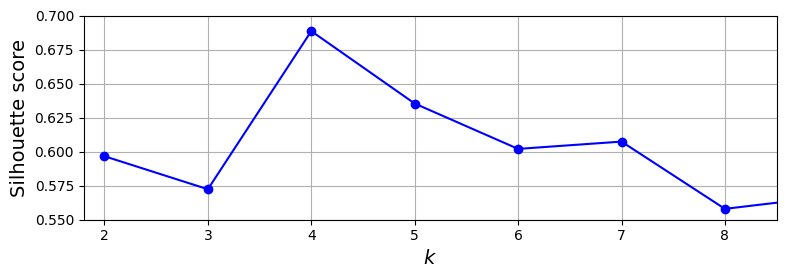

In [45]:
# extra code – this cell generates and saves Figure 9–9

# k=2부터 9까지 클러스터 수에 대한 실루엣 점수 계산
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.axis([1.8, 8.5, 0.55, 0.7])
plt.grid()
save_fig("silhouette_score_vs_k_plot")
plt.show()

As you can see, this visualization is much richer than the previous one: in particular, although it confirms that $k=4$ is a very good choice, but it also underlines the fact that $k=5$ is quite good as well.

An even more informative visualization is given when you plot every instance's silhouette coefficient, sorted by the cluster they are assigned to and by the value of the coefficient. This is called a _silhouette diagram_:

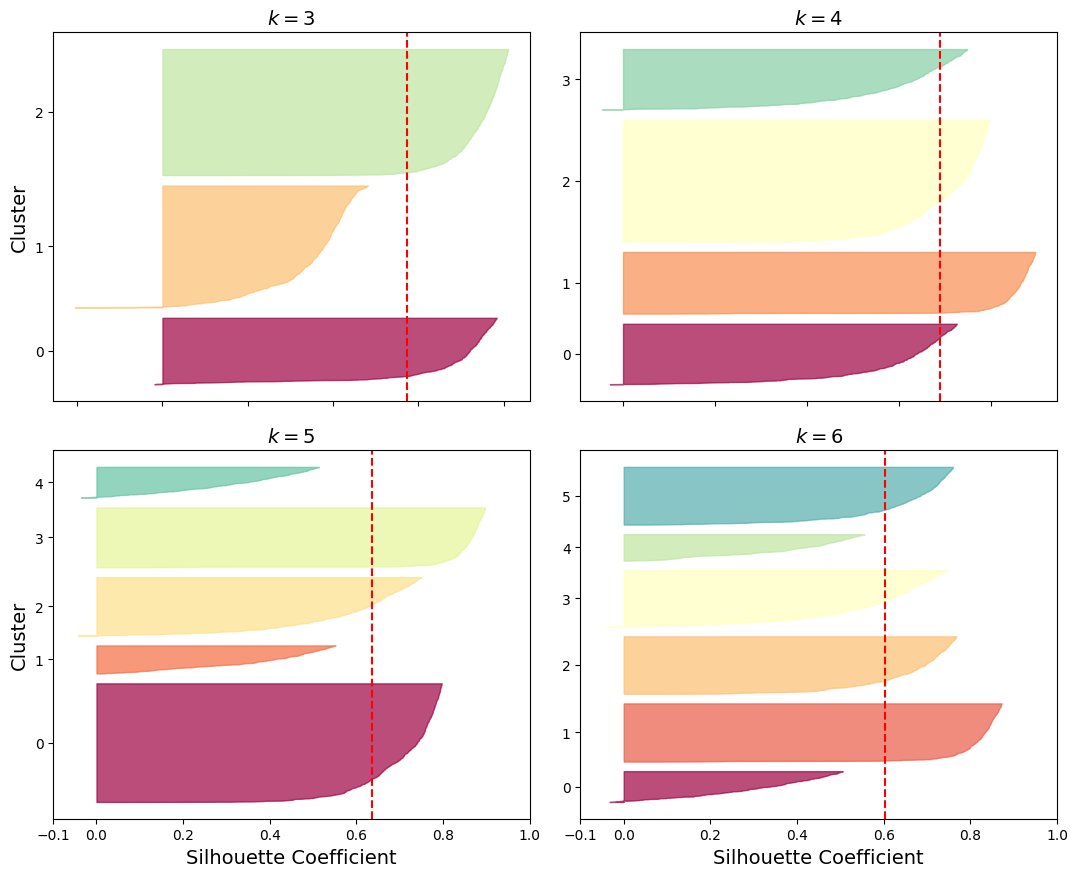

In [46]:
# extra code – this cell generates and saves Figure 9–10

from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.figure(figsize=(11, 9))

# k=3, 4, 5, 6에 대해 개별 실루엣 계수 분포 시각화
for k in (3, 4, 5, 6):
    plt.subplot(2, 2, k - 2)  # 2x2 서브플롯 배치

    # 각 샘플의 클러스터 라벨
    y_pred = kmeans_per_k[k - 1].labels_
    # 샘플별 실루엣 계수
    silhouette_coefficients = silhouette_samples(X, y_pred)

    # 클러스터 사이 시각적 여백
    padding = len(X) // 30
    pos = padding # 현재 y 위치
    ticks = []  # 클러스터 레이블 표시용 y 위치 저장

    # 클러스터별 실루엣 계수 막대 시각화
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = plt.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    # y축: 클러스터 레이블 설정
    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (5, 6):
        # x축 레이블 설정 (일부 subplot만)
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        # x축 레이블 제거
        plt.tick_params(labelbottom=False)

    # 전체 평균 실루엣 점수 표시 (세로 빨간 점선)
    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$")

save_fig("silhouette_analysis_plot")
plt.show()

As you can see, $k=5$ looks like the best option here, as all clusters are roughly the same size, and they all cross the dashed line, which represents the mean silhouette score.

## Limits of K-Means

Let's generate a more difficult dataset, with elongated blobs and varying densities, and show that K-Means struggles to cluster it correctly:

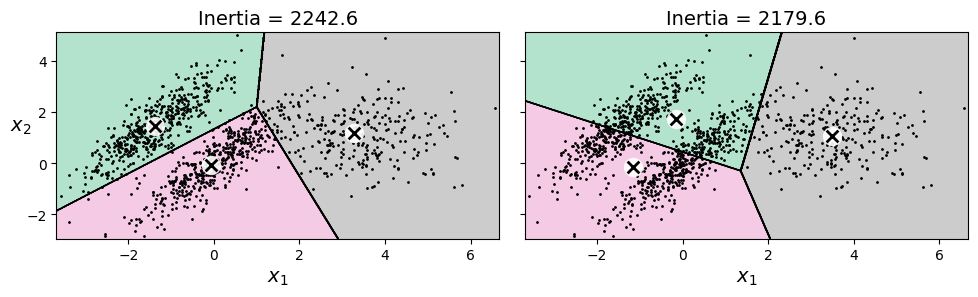

In [47]:
# extra code – this cell generates and saves Figure 9–11

# 두 개의 밀도와 분산이 다른 군집(X1, X2)을 생성하여 병합
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
# 비대칭으로 늘리기 (선형 변환)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)

# X2를 오른쪽 아래로 이동
X2 = X2 + [6, -8]

# 두 데이터셋 병합
X = np.r_[X1, X2]
y = np.r_[y1, y2]

# 두 개의 KMeans 모델 학습: 하나는 좋은 초기화 사용
# 수동 초기화
kmeans_good = KMeans(n_clusters=3,
                     init=np.array([[-1.5, 2.5], [0.5, 0], [4, 0]]),
                     n_init=1, random_state=42)
# 다른 하나는 기본 설정
kmeans_bad = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_good.fit(X)
kmeans_bad.fit(X)

# 결과 시각화
plt.figure(figsize=(10, 3.2))

# 왼쪽: 좋은 초기화
plt.subplot(121)
plot_decision_boundaries(kmeans_good, X)
plt.title(f"Inertia = {kmeans_good.inertia_:.1f}")

# 오른쪽: 일반적인 초기화 (성능 저하)
plt.subplot(122)
plot_decision_boundaries(kmeans_bad, X, show_ylabels=False)
plt.title(f"Inertia = {kmeans_bad.inertia_:.1f}")

save_fig("bad_kmeans_plot")
plt.show()

## Using Clustering for Image Segmentation

Download the ladybug image:

In [48]:
# extra code – downloads the ladybug image
# ladybug 이미지를 다운로드 받는 코드

import urllib.request

# GitHub에서 제공되는 이미지 파일 기본 경로
homl3_root = "https://github.com/ageron/handson-ml3/raw/main/"
filename = "ladybug.png"
filepath = IMAGES_PATH / filename

# 파일이 로컬에 없으면 다운로드
if not filepath.is_file():
    print("Downloading", filename)
    url = f"{homl3_root}/images/unsupervised_learning/{filename}"
    urllib.request.urlretrieve(url, filepath)

In [49]:
import PIL

image = np.asarray(PIL.Image.open(filepath))
image.shape

(533, 800, 3)

In [50]:
# 이미지를 (픽셀 수, RGB 3채널) 형태의 2차원 배열로 변환
X = image.reshape(-1, 3)

# K-Means 클러스터링 수행 (8개의 색상 클러스터)
kmeans = KMeans(n_clusters=8, n_init=10, random_state=42).fit(X)

# 각 픽셀의 라벨을 해당 클러스터 중심 색으로 대체하여 색상 축소
segmented_img = kmeans.cluster_centers_[kmeans.labels_]

# 원래 이미지 형태로 다시 변환 (세그먼트된 이미지 복원)
segmented_img = segmented_img.reshape(image.shape)

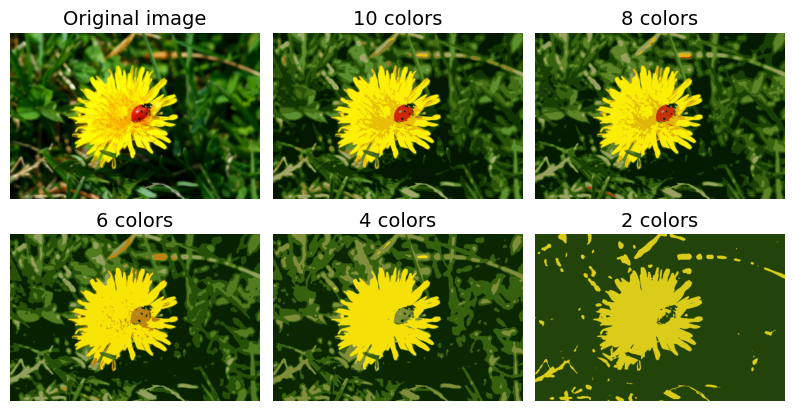

In [51]:
# extra code – this cell generates and saves Figure 9–12
# Figure 9–12: K-Means를 이용한 이미지 색상 세분화 시각화

# 세분화된 이미지 결과 저장 리스트
segmented_imgs = []

# 사용할 클러스터(색상 수) 개수
n_colors = (10, 8, 6, 4, 2)
for n_clusters in n_colors:
    # KMeans 학습
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(X)
    # 각 픽셀을 클러스터 중심 색으로 대체
    segmented_img = kmeans.cluster_centers_[kmeans.labels_]
    # 원래 이미지 shape으로 복원
    segmented_imgs.append(segmented_img.reshape(image.shape))

# 시각화: 원본 + 클러스터 개수별 색상 압축 이미지
plt.figure(figsize=(10, 5))
plt.subplots_adjust(wspace=0.05, hspace=0.1)

plt.subplot(2, 3, 1)
plt.imshow(image) # 원본
plt.title("Original image")
plt.axis('off')

# 10, 8, 6, 4, 2 색상 수에 해당하는 이미지 출력
for idx, n_clusters in enumerate(n_colors):
    plt.subplot(2, 3, 2 + idx)
    # 픽셀 값이 [0, 255]이므로 0~1로 정규화
    plt.imshow(segmented_imgs[idx] / 255)
    plt.title(f"{n_clusters} colors")
    plt.axis('off')

save_fig('image_segmentation_plot', tight_layout=False)
plt.show()

## Using Clustering for Semi-Supervised Learning

Another use case for clustering is semi-supervised learning, when we have plenty of unlabeled instances and very few labeled instances.

Let's tackle the _digits dataset_ which is a simple MNIST-like dataset containing 1,797 grayscale 8×8 images representing digits 0 to 9.

In [52]:
from sklearn.datasets import load_digits

# digits 데이터셋 로드
# X_digits는 이미지 데이터 (8x8 = 64차원), y_digits는 정답 레이블
X_digits, y_digits = load_digits(return_X_y=True)
# 훈련 세트: 처음 1400개 샘플
X_train, y_train = X_digits[:1400], y_digits[:1400]
# 테스트 세트: 나머지 샘플 (1400번째 이후)
X_test, y_test = X_digits[1400:], y_digits[1400:]

Let's look at the performance of a logistic regression model when we only have 50 labeled instances:

In [53]:
from sklearn.linear_model import LogisticRegression
# 사용할 라벨 데이터 수를 50개로 제한
# semi-supervised 또는 label-efficient 상황을 시뮬레이션
n_labeled = 50
# 로지스틱 회귀 모델 생성
# 최대 반복 횟수를 10,000으로 설정해 수렴 문제 방지
log_reg = LogisticRegression(max_iter=10_000)
# 훈련 데이터 중 처음 50개 샘플만 사용하여 모델 훈련
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

LogisticRegression(max_iter=10000)

In [54]:
log_reg.score(X_test, y_test)

0.7581863979848866

In [55]:
# extra code – measure the accuracy when we use the whole training set
# 전체 훈련 데이터를 사용하여 새로운 로지스틱 회귀 모델 생성
log_reg_full = LogisticRegression(max_iter=10_000)

# 전체 1400개의 훈련 샘플로 모델 학습
log_reg_full.fit(X_train, y_train)

# 테스트 세트에 대한 정확도(Accuracy) 평가
log_reg_full.score(X_test, y_test)

0.9093198992443325

It's much less than earlier of course. Let's see how we can do better. First, let's cluster the training set into 50 clusters, then for each cluster let's find the image closest to the centroid. We will call these images the representative images:

In [56]:
k = 50
# KMeans 클러스터링 모델 생성 (클러스터 수: 50)
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)

# 각 샘플이 각 클러스터 중심까지 얼마나 먼지 계산 (유클리디안 거리)
X_digits_dist = kmeans.fit_transform(X_train)

# 각 클러스터에 대해 중심에서 가장 가까운 샘플의 인덱스 찾기
representative_digit_idx = X_digits_dist.argmin(axis=0)

# 각 클러스터를 대표하는 숫자 이미지 추출
X_representative_digits = X_train[representative_digit_idx]

Now let's plot these representative images and label them manually:

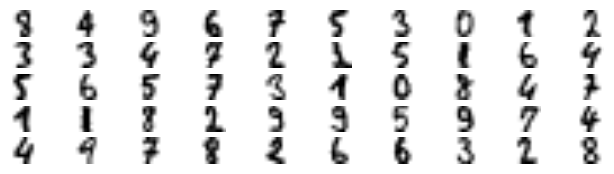

In [57]:
# extra code – this cell generates and saves Figure 9–13

plt.figure(figsize=(8, 2))
# 클러스터 개수만큼 반복하여 각 대표 이미지 시각화
for index, X_representative_digit in enumerate(X_representative_digits):
    # 10열로 구성된 서브플롯에 각 이미지 배치
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary",
               interpolation="bilinear")
    plt.axis('off')

save_fig("representative_images_plot", tight_layout=False)
plt.show()

In [58]:
y_representative_digits = np.array([
    1, 3, 6, 0, 7, 9, 2, 4, 8, 9,
    5, 4, 7, 1, 2, 6, 1, 2, 5, 1,
    4, 1, 3, 3, 8, 8, 2, 5, 6, 9,
    1, 4, 0, 6, 8, 3, 4, 6, 7, 2,
    4, 1, 0, 7, 5, 1, 9, 9, 3, 7
])

Now we have a dataset with just 50 labeled instances, but instead of being completely random instances, each of them is a representative image of its cluster. Let's see if the performance is any better:

In [59]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

0.06801007556675064

Wow! We jumped from 74.8% accuracy to 84.9%, although we are still only training the model on 50 instances. Since it's often costly and painful to label instances, especially when it has to be done manually by experts, it's a good idea to make them label representative instances rather than just random instances.

But perhaps we can go one step further: what if we propagated the labels to all the other instances in the same cluster?

In [60]:
# 전파된 라벨들을 저장할 배열 생성
# 정수형, 크기는 학습 샘플 수와 동일
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
    # 클러스터 i에 속한 모든 샘플에 대해
    # 해당 클러스터의 대표 샘플(y_representative_digits[i])의 라벨을 부여
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

In [61]:
# 로지스틱 회귀 모델 객체 생성
log_reg = LogisticRegression(max_iter=10_000)
# 클러스터 기반으로 전파된 라벨(y_train_propagated)을 사용하여 모델 학습
log_reg.fit(X_train, y_train_propagated)

LogisticRegression(max_iter=10000)

In [62]:
log_reg.score(X_test, y_test)

0.07808564231738035

We got another significant accuracy boost! Let's see if we can do even better by ignoring the 1% instances that are farthest from their cluster center: this should eliminate some outliers:

In [63]:
# 가장 가까운 99% 샘플만 신뢰도 높은 샘플로 간주
percentile_closest = 99
# 각 샘플이 속한 클러스터 중심과의 거리 계산
# 자기 클러스터 중심까지의 거리
X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]

# 클러스터별로 반복
for i in range(k):
    # 해당 클러스터에 속한 샘플 인덱스 불리언 마스크
    in_cluster = (kmeans.labels_ == i)
    # 클러스터 내의 샘플들의 중심과의 거리
    cluster_dist = X_cluster_dist[in_cluster]
    # 중심과 가까운 상위 99% 이내 거리 임계값 (percentile 기준)
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    # 해당 임계값보다 멀리 떨어진 샘플은 신뢰도 낮다고 판단
    above_cutoff = (X_cluster_dist > cutoff_distance)
    # 위 조건을 모두 만족하는 샘플은 라벨 제거(-1로 설정)
    X_cluster_dist[in_cluster & above_cutoff] = -1

# -1이 아닌 샘플들만 남김 (신뢰도 높은 샘플)
partially_propagated = (X_cluster_dist != -1)

# 해당 조건을 만족하는 샘플만 학습에 사용
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [64]:
# 로지스틱 회귀 모델 생성
# 최대 반복 횟수는 10,000으로 설정하여 수렴 문제 방지
log_reg = LogisticRegression(max_iter=10_000)

# 훈련: 클러스터 중심과 가까운 신뢰도 높은 샘플만 사용
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)

# 테스트 세트에 대한 분류 정확도 측정
log_reg.score(X_test, y_test)

0.07808564231738035

Wow, another accuracy boost! We have even slightly surpassed the performance we got by training on the fully labeled training set!

Our propagated labels are actually pretty good: their accuracy is about 97.6%:

In [65]:
(y_train_partially_propagated == y_train[partially_propagated]).mean()

np.float64(0.09481481481481481)

You could now do a few iterations of *active learning*:
1. Manually label the instances that the classifier is least sure about, if possible by picking them in distinct clusters.
2. Train a new model with these additional labels.

## DBSCAN

In [66]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# make_moons: 반달 모양의 비선형 구조를 가진 데이터 생성 (노이즈 포함)
X, y = make_moons(n_samples=1000, noise=0.05, random_state=42)

# DBSCAN 모델 생성
# eps: 두 샘플이 같은 이웃으로 간주되기 위한 최대 거리 (작을수록 민감도 ↑)
# min_samples: 핵심 포인트가 되기 위한 최소 이웃 수
dbscan = DBSCAN(eps=0.05, min_samples=5)

# DBSCAN 모델 학습 (비지도 학습이므로 y는 사용하지 않음)
dbscan.fit(X)

DBSCAN(eps=0.05)

In [67]:
dbscan.labels_[:10]

array([ 0,  2, -1, -1,  1,  0,  0,  0,  2,  5])

In [68]:
dbscan.core_sample_indices_[:10]

array([ 0,  4,  5,  6,  7,  8, 10, 11, 12, 13])

In [69]:
dbscan.components_

array([[-0.02137124,  0.40618608],
       [-0.84192557,  0.53058695],
       [ 0.58930337, -0.32137599],
       ...,
       [ 1.66258462, -0.3079193 ],
       [-0.94355873,  0.3278936 ],
       [ 0.79419406,  0.60777171]])

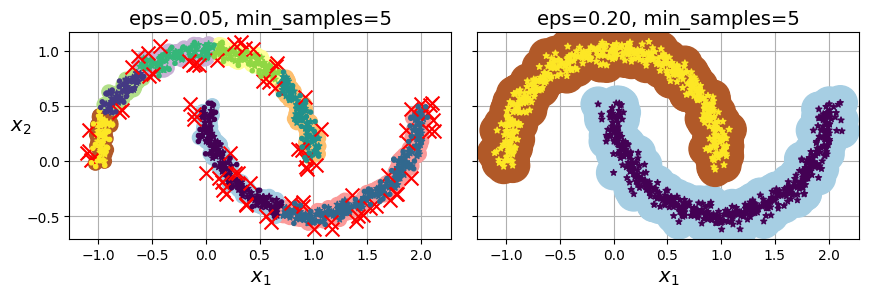

In [70]:
# extra code – this cell generates and saves Figure 9–14
# 시각화를 위한 DBSCAN 결과 시각화 함수 정의

def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    # 핵심 샘플 인덱스를 이용한 마스크 생성
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    # 이상치(노이즈) 마스크 생성 (-1로 라벨링된 샘플들)
    anomalies_mask = dbscan.labels_ == -1
    # 핵심도 아니고 노이즈도 아닌 나머지 샘플들 (경계 샘플)
    non_core_mask = ~(core_mask | anomalies_mask)

    # 핵심 샘플, 이상치, 경계 샘플 데이터 추출
    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]

    # 핵심 샘플: 큰 원으로 색상 표시
    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")

    # 핵심 샘플 중심: 작은 별로 표시
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20,
                c=dbscan.labels_[core_mask])
    # 이상치: 빨간 X로 표시
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    # 경계 샘플: 작은 점으로 표시
    plt.scatter(non_cores[:, 0], non_cores[:, 1],
                c=dbscan.labels_[non_core_mask], marker=".")
    # 축 레이블 설정
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
    plt.grid()
    plt.gca().set_axisbelow(True)

# 두 번째 DBSCAN 클러스터링: 더 큰 eps로 실행
dbscan2 = DBSCAN(eps=0.2)
dbscan2.fit(X)

plt.figure(figsize=(9, 3.2))

# 첫 번째 DBSCAN 결과 시각화 (기존 eps=0.05)
plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

# 두 번째 DBSCAN 결과 시각화 (eps=0.2)
plt.subplot(122)
plot_dbscan(dbscan2, X, size=600, show_ylabels=False)

save_fig("dbscan_plot")
plt.show()

In [71]:
dbscan = dbscan2  # extra code – the text says we now use eps=0.2

In [72]:
from sklearn.neighbors import KNeighborsClassifier

# k-NN 분류기 생성: 이웃 개수를 50으로 설정
knn = KNeighborsClassifier(n_neighbors=50)

# DBSCAN의 핵심 샘플(components_)과 해당 라벨(core_sample_indices_)로 학습
# components_: 클러스터 중심이 되는 핵심 샘플들의 좌표
# labels_[core_sample_indices_]: 해당 핵심 샘플들의 클러스터 라벨
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)

In [73]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)

array([1, 0, 1, 0])

In [74]:
knn.predict_proba(X_new)

array([[0.18, 0.82],
       [1.  , 0.  ],
       [0.12, 0.88],
       [1.  , 0.  ]])

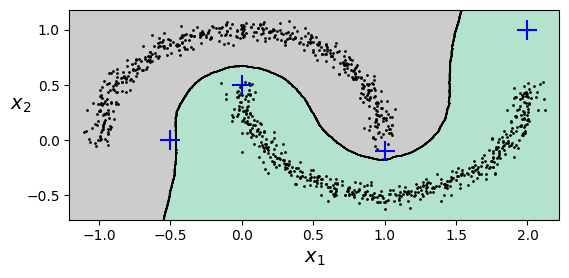

In [75]:
# extra code – this cell generates and saves Figure 9–15
# DBSCAN의 핵심 샘플 기반 k-NN 분류기를 통한 클러스터 결정 경계 시각화

plt.figure(figsize=(6, 3))
plot_decision_boundaries(knn, X, show_centroids=False)
plt.scatter(X_new[:, 0], X_new[:, 1], c="b", marker="+", s=200, zorder=10)
save_fig("cluster_classification_plot")
plt.show()

In [76]:
# knn.kneighbors()를 통해 각 새로운 샘플(X_new)에서 가장 가까운
# core sample까지의 거리(y_dist)와 그 인덱스(y_pred_idx)를 구함
y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)

# core_sample_indices_에서 가장 가까운 샘플의 클러스터 라벨을 가져옴
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]

# 거리가 0.2를 초과하는 경우는 이상치(-1)로 지정
y_pred[y_dist > 0.2] = -1

y_pred.ravel()  #-1은 이상치(noise)

array([-1,  0,  1, -1])

## Other Clustering Algorithms

The code in this section is bonus material, not in the book.

### Spectral Clustering

In [77]:
from sklearn.cluster import SpectralClustering

In [78]:
# gamma=100은 RBF 커널의 감도를 조정하는 파라미터
# 높을수록 가까운 점들만 유사하게 간주
sc1 = SpectralClustering(n_clusters=2, gamma=100, random_state=42)
sc1.fit(X)

SpectralClustering(gamma=100, n_clusters=2, random_state=42)

In [79]:
sc1.affinity_matrix_.round(2)

array([[1. , 0. , 0. , ..., 0. , 0. , 0. ],
       [0. , 1. , 0.3, ..., 0. , 0. , 0. ],
       [0. , 0.3, 1. , ..., 0. , 0. , 0. ],
       ...,
       [0. , 0. , 0. , ..., 1. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 1. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 1. ]])

In [80]:
# Spectral Clustering 수행
# RBF 커널의 gamma 값을 1로 설정 (유사도 계산 범위가 넓어짐)
sc2 = SpectralClustering(n_clusters=2, gamma=1, random_state=42)
sc2.fit(X)

SpectralClustering(gamma=1, n_clusters=2, random_state=42)

In [81]:
# 군집 결과를 시각화하는 함수 정의
def plot_spectral_clustering(sc, X, size, alpha, show_xlabels=True,
                             show_ylabels=True):
    # 배경 점: 회색, 반투명 (원래 분포)
    plt.scatter(X[:, 0], X[:, 1], marker='o', s=size, c='gray', alpha=alpha)
    # 흰 점: 시각적으로 중심 강조
    plt.scatter(X[:, 0], X[:, 1], marker='o', s=30, c='w')
    # 군집 결과를 색상으로 표시
    plt.scatter(X[:, 0], X[:, 1], marker='.', s=10, c=sc.labels_, cmap="Paired")

    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"RBF gamma={sc.gamma}")

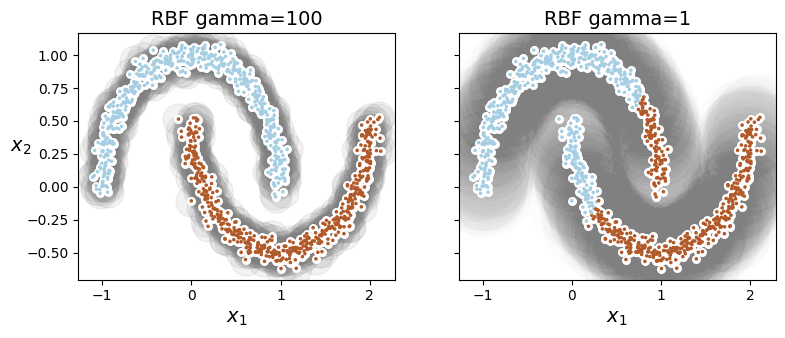

In [82]:
plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_spectral_clustering(sc1, X, size=500, alpha=0.1)

plt.subplot(122)
plot_spectral_clustering(sc2, X, size=4000, alpha=0.01, show_ylabels=False)

plt.show()

### Agglomerative Clustering

In [83]:
from sklearn.cluster import AgglomerativeClustering

In [84]:
# 1D 데이터 예시: 거리 기반 계층적 군집을 확인하기 위한 간단한 1차원 배열
X = np.array([0, 2, 5, 8.5]).reshape(-1, 1)

# 완전 연결(complete linkage) 방식으로 병합 군집 수행
agg = AgglomerativeClustering(linkage="complete").fit(X)

In [85]:
# 학습 후 estimator가 갖는 학습된 속성 목록을 반환
def learned_parameters(estimator):
    return [attrib for attrib in dir(estimator)
            if attrib.endswith("_") and not attrib.startswith("_")]

In [86]:
learned_parameters(agg)

['children_',
 'labels_',
 'n_clusters_',
 'n_connected_components_',
 'n_features_in_',
 'n_leaves_']

In [87]:
agg.children_

array([[0, 1],
       [2, 3],
       [4, 5]])

# Gaussian Mixtures

Let's generate the same dataset as earliers with three ellipsoids (the one K-Means had trouble with):

In [88]:
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)

# 비대칭 타원형 회전
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8] # 더 떨어진 클러스터 추가
X = np.r_[X1, X2]
y = np.r_[y1, y2]

Let's train a Gaussian mixture model on the previous dataset:

In [89]:
from sklearn.mixture import GaussianMixture

In [90]:
# GMM 모델 학습, 클러스터 3
# EM 알고리즘을 10번 실행하고 최적 해를 선택
gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)

GaussianMixture(n_components=3, n_init=10, random_state=42)

Let's look at the parameters that the EM algorithm estimated:

In [91]:
# 각 Gaussian 성분의 mixing weight (상대적 비율)
gm.weights_

array([0.40005972, 0.20961444, 0.39032584])

In [92]:
# 각 Gaussian의 중심 (평균)
gm.means_

array([[-1.40764129,  1.42712848],
       [ 3.39947665,  1.05931088],
       [ 0.05145113,  0.07534576]])

In [93]:
# 각 Gaussian의 공분산 행렬 (모양, 방향, 스케일을 결정)
gm.covariances_

array([[[ 0.63478217,  0.72970097],
        [ 0.72970097,  1.16094925]],

       [[ 1.14740131, -0.03271106],
        [-0.03271106,  0.95498333]],

       [[ 0.68825143,  0.79617956],
        [ 0.79617956,  1.21242183]]])

Did the algorithm actually converge?

In [94]:
# 수렴 여부
gm.converged_

True

Yes, good. How many iterations did it take?

In [95]:
# 반복 횟수
gm.n_iter_

4

You can now use the model to predict which cluster each instance belongs to (hard clustering) or the probabilities that it came from each cluster. For this, just use `predict()` method or the `predict_proba()` method:

In [96]:
# 각 샘플 X[i]에 대해, 가장 높은 확률의 Gaussian 성분(클러스터)에 할당
gm.predict(X)

array([2, 2, 0, ..., 1, 1, 1])

In [97]:
# 각 샘플이 각 클러스터에 속할 확률
gm.predict_proba(X).round(3)

array([[0.   , 0.023, 0.977],
       [0.001, 0.016, 0.983],
       [1.   , 0.   , 0.   ],
       ...,
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ]])

This is a generative model, so you can sample new instances from it (and get their labels):

In [98]:
# 새로운 샘플 생성
X_new, y_new = gm.sample(6)
X_new

array([[-2.32491052,  1.04752548],
       [-1.16654983,  1.62795173],
       [ 1.84860618,  2.07374016],
       [ 3.98304484,  1.49869936],
       [ 3.8163406 ,  0.53038367],
       [ 0.38079484, -0.56239369]])

In [99]:
y_new

array([0, 0, 1, 1, 1, 2])

Notice that they are sampled sequentially from each cluster.

You can also estimate the log of the _probability density function_ (PDF) at any location using the `score_samples()` method:

In [100]:
# 확률 밀도 함수(PDF)의 로그 값 계산
# 각 데이터 포인트가 해당 모델에 얼마나 잘 맞는지를 측정
gm.score_samples(X).round(2)

array([-2.61, -3.57, -3.33, ..., -3.51, -4.4 , -3.81])

Let's check that the PDF integrates to 1 over the whole space. We just take a large square around the clusters, and chop it into a grid of tiny squares, then we compute the approximate probability that the instances will be generated in each tiny square (by multiplying the PDF at one corner of the tiny square by the area of the square), and finally summing all these probabilities). The result is very close to 1:

In [101]:
# extra code – bonus material
# GMM이 유효한 확률 분포인지 확인
# 전체 공간에서 적분값이 1에 가까운지를 검증
resolution = 100
grid = np.arange(-10, 10, 1 / resolution)
xx, yy = np.meshgrid(grid, grid)
X_full = np.vstack([xx.ravel(), yy.ravel()]).T

# 로그값 → 확률값
pdf = np.exp(gm.score_samples(X_full))
# 각 셀 면적
pdf_probas = pdf * (1 / resolution) ** 2
pdf_probas.sum()

np.float64(0.9999999999225088)

Now let's plot the resulting decision boundaries (dashed lines) and density contours:

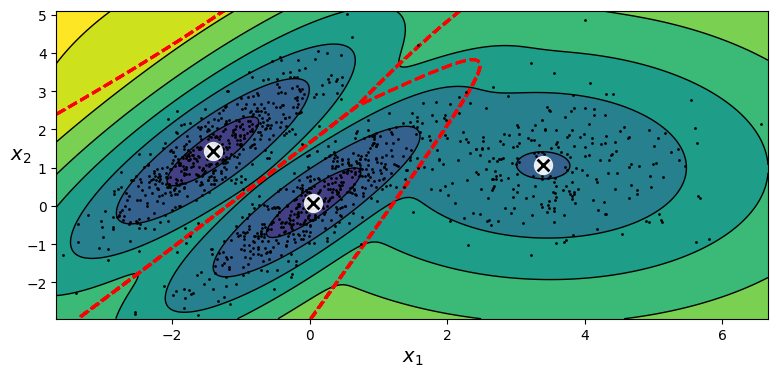

In [102]:
# extra code – this cells generates and saves Figure 9–16
# Figure 9-16을 생성하고 저장하는 코드

from matplotlib.colors import LogNorm

# GMM 클러스터 결과 시각화 함수 정의
def plot_gaussian_mixture(clusterer, X, resolution=1000, show_ylabels=True):
    # 데이터 범위 설정
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    # x1, x2의 그리드 좌표 생성 (해상도에 따라)
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    # 각 격자점의 로그 확률 밀도 계산 후 음수화 (낮을수록 진한 색)
    Z = -clusterer.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 밀도 등고선 그림 (확률이 높은 영역을 색으로 표시)
    plt.contourf(xx, yy, Z,
                 # 로그 스케일
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 # 로그 스케일 등고선 레벨
                 levels=np.logspace(0, 2, 12))

    # 밀도 등고선 테두리 추가 (검정 실선)
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k')

    # 결정 경계 시각화 (클러스터 할당 결과에 기반)
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z,
                linewidths=2, colors='r', linestyles='dashed')
    # 원래 데이터 포인트 시각화
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

    # 클러스터 중심 및 가중치에 따라 크기 표시
    plot_centroids(clusterer.means_, clusterer.weights_)

    # 라벨 설정
    plt.xlabel("$x_1$")
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))

plot_gaussian_mixture(gm, X)

save_fig("gaussian_mixtures_plot")
plt.show()

You can impose constraints on the covariance matrices that the algorithm looks for by setting the `covariance_type` hyperparameter:
* `"spherical"`: all clusters must be spherical, but they can have different diameters (i.e., different variances).
* `"diag"`: clusters can take on any ellipsoidal shape of any size, but the ellipsoid's axes must be parallel to the axes (i.e., the covariance matrices must be diagonal).
* `"tied"`: all clusters must have the same shape, which can be any ellipsoid (i.e., they all share the same covariance matrix).
* `"full"` (default): no constraint, all clusters can take on any ellipsoidal shape of any size.

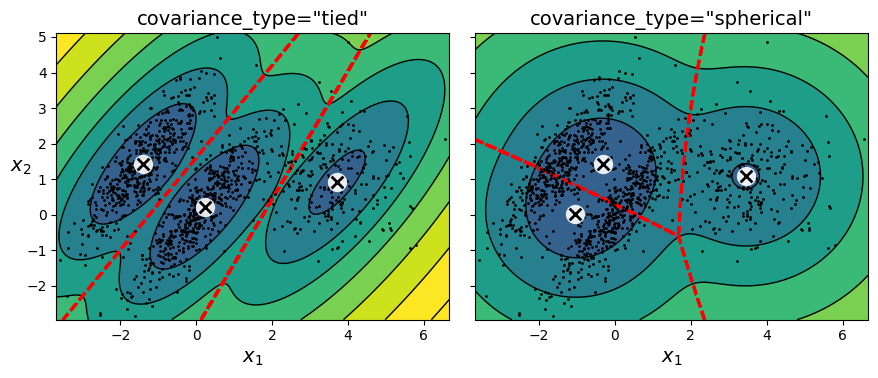

In [103]:
# extra code – this cell generates and saves Figure 9–17
# 공분산 행렬 제약 조건별 GMM 비교 시각화 (Figure 9-17)

# 다양한 공분산 타입을 가진 GMM 모델 정의

# 완전 자유 형태 (기본값)
gm_full = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="full", random_state=42)
# 동일한 공분산 행렬 공유
gm_tied = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="tied", random_state=42)
# 원형 (반지름만 다름)
gm_spherical = GaussianMixture(n_components=3, n_init=10,
                               covariance_type="spherical", random_state=42)
# 대각 행렬 (축과 평행한 타원)
gm_diag = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="diag", random_state=42)

gm_full.fit(X)
gm_tied.fit(X)
gm_spherical.fit(X)
gm_diag.fit(X)

# 두 개의 GMM 모델을 비교하여 시각
def compare_gaussian_mixtures(gm1, gm2, X):
    plt.figure(figsize=(9, 4))

    # 첫 번째 GMM 모델 시각화 (왼쪽)
    plt.subplot(121)
    plot_gaussian_mixture(gm1, X)
    plt.title(f'covariance_type="{gm1.covariance_type}"')
    # 두 번째 GMM 모델 시각화 (오른쪽)
    plt.subplot(122)
    plot_gaussian_mixture(gm2, X, show_ylabels=False)
    plt.title(f'covariance_type="{gm2.covariance_type}"')

compare_gaussian_mixtures(gm_tied, gm_spherical, X)

save_fig("covariance_type_plot")
plt.show()

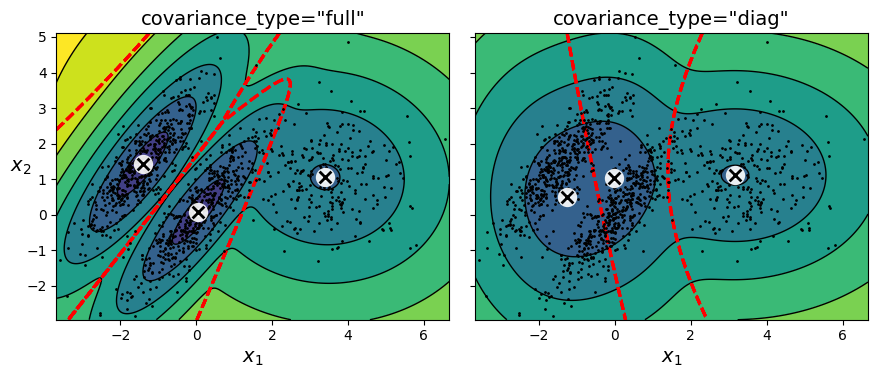

In [104]:
# extra code – comparing covariance_type="full" and covariance_type="diag"
# 추가 비교: full vs diag
compare_gaussian_mixtures(gm_full, gm_diag, X)
plt.tight_layout()
plt.show()

## Anomaly Detection Using Gaussian Mixtures

Gaussian Mixtures can be used for _anomaly detection_: instances located in low-density regions can be considered anomalies. You must define what density threshold you want to use. For example, in a manufacturing company that tries to detect defective products, the ratio of defective products is usually well-known. Say it is equal to 2%, then you can set the density threshold to be the value that results in having 2% of the instances located in areas below that threshold density:

In [105]:
# Gaussian Mixture 모델을 활용한 이상치 탐지 (Figure 9-18)

# 각 데이터 포인트의 로그 확률 밀도
# log probability density 계산
densities = gm.score_samples(X)

# 하위 2%의 밀도에 해당하는 임계값(threshold) 계산
# 예: 제조 불량률이 2%일 때, 하위 2% 밀도 아래는 이상치로 간주
density_threshold = np.percentile(densities, 2)

# 밀도 임계값보다 작은 점들을 이상치로 분류
anomalies = X[densities < density_threshold]

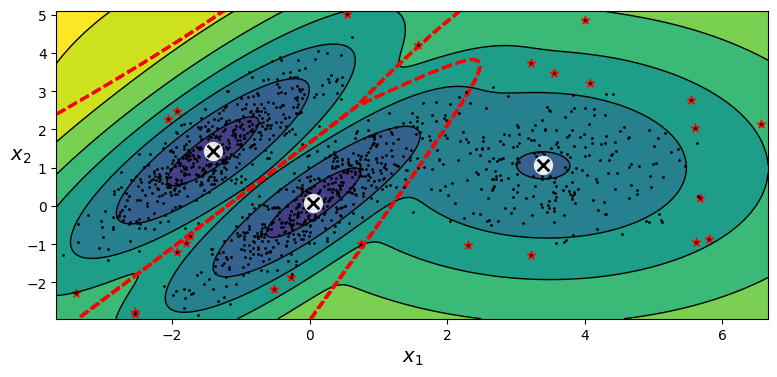

In [106]:
# extra code – this cell generates and saves Figure 9–18
# 이상치 포함된 GMM 결과 시각화
plt.figure(figsize=(8, 4))

# GMM의 밀도 등고선 및 결정 경계 시각화
plot_gaussian_mixture(gm, X)

# 이상치를 빨간 별표(*)로 표시
plt.scatter(anomalies[:, 0], anomalies[:, 1], color='r', marker='*')

# y축 상한선 조정 (이상치가 잘 보이도록)
plt.ylim(top=5.1)

save_fig("mixture_anomaly_detection_plot")
plt.show()

## Selecting the Number of Clusters

We cannot use the inertia or the silhouette score because they both assume that the clusters are spherical. Instead, we can try to find the model that minimizes a theoretical information criterion such as the Bayesian Information Criterion (BIC) or the Akaike Information Criterion (AIC):

${BIC} = {\log(m)p - 2\log({\hat L})}$

${AIC} = 2p - 2\log(\hat L)$

* $m$ is the number of instances.
* $p$ is the number of parameters learned by the model.
* $\hat L$ is the maximized value of the likelihood function of the model. This is the conditional probability of the observed data $\mathbf{X}$, given the model and its optimized parameters.

Both BIC and AIC penalize models that have more parameters to learn (e.g., more clusters), and reward models that fit the data well (i.e., models that give a high likelihood to the observed data).

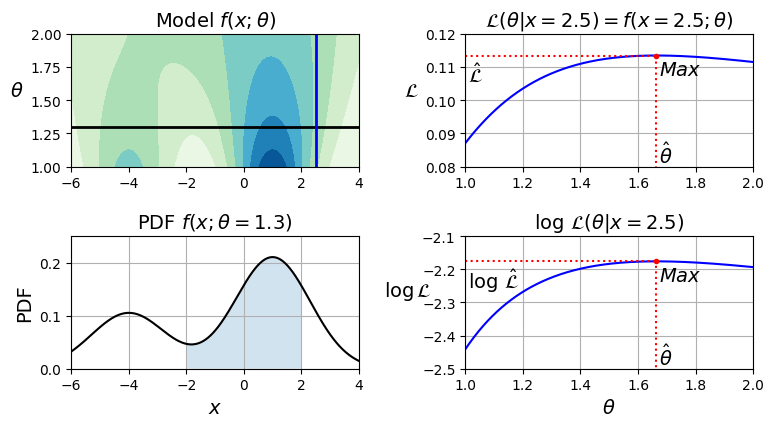

In [107]:
# extra code – this cell generates and saves Figure 9–19

from scipy.stats import norm

# 예시 값 설정
x_val = 2.5 # 관심 있는 입력값
std_val = 1.3 # 예시 표준편차 (θ로 간주)
x_range = [-6, 4]
x_proba_range = [-2, 2]  # 확률 질량을 확인할 x 범위
stds_range = [1, 2] # θ (표준편차) 범위

# x, θ 값들의 조합으로 이차원 그리드 생성
xs = np.linspace(x_range[0], x_range[1], 501)
stds = np.linspace(stds_range[0], stds_range[1], 501)
Xs, Stds = np.meshgrid(xs, stds)

# 두 개의 정규분포 혼합 모델: f(x; θ)
Z = 2 * norm.pdf(Xs - 1.0, 0, Stds) + norm.pdf(Xs + 4.0, 0, Stds)

# 정규화 수행 (전체 확률합이 1이 되도록)
Z = Z / Z.sum(axis=1)[:, np.newaxis] / (xs[1] - xs[0])

# 시각화용 인덱스 계산
# x=2.5에 가장 가까운 index
x_example_idx = (xs >= x_val).argmax()  # index of the first value >= x_val

 # L(θ|x=2.5)의 최대값 index
max_idx = Z[:, x_example_idx].argmax()
max_val = Z[:, x_example_idx].max()

# θ=1.3에 가까운 index
s_example_idx = (stds >= std_val).argmax()
x_range_min_idx = (xs >= x_proba_range[0]).argmax()
x_range_max_idx = (xs >= x_proba_range[1]).argmax()
log_max_idx = np.log(Z[:, x_example_idx]).argmax()
log_max_val = np.log(Z[:, x_example_idx]).max()

plt.figure(figsize=(8, 4.5))

# (1) θ에 따른 f(x; θ) 곡면 그래프 (등고선 형태)
plt.subplot(2, 2, 1)
plt.contourf(Xs, Stds, Z, cmap="GnBu")
plt.plot([-6, 4], [std_val, std_val], "k-", linewidth=2)
plt.plot([x_val, x_val], [1, 2], "b-", linewidth=2)
plt.ylabel(r"$\theta$", rotation=0, labelpad=10)
plt.title(r"Model $f(x; \theta)$")

# (2) L(θ|x=2.5)의 곡선
plt.subplot(2, 2, 2)
plt.plot(stds, Z[:, x_example_idx], "b-")
plt.plot(stds[max_idx], max_val, "r.")
plt.plot([stds[max_idx], stds[max_idx]], [0, max_val], "r:")
plt.plot([0, stds[max_idx]], [max_val, max_val], "r:")
plt.text(stds[max_idx]+ 0.01, 0.081, r"$\hat{\theta}$")
plt.text(stds[max_idx]+ 0.01, max_val - 0.006, r"$Max$")
plt.text(1.01, max_val - 0.008, r"$\hat{\mathcal{L}}$")
plt.ylabel(r"$\mathcal{L}$", rotation=0, labelpad=10)
plt.title(fr"$\mathcal{{L}}(\theta|x={x_val}) = f(x={x_val}; \theta)$")
plt.grid()
plt.axis([1, 2, 0.08, 0.12])

# (3) 특정 θ(=1.3)일 때의 PDF 시각화
plt.subplot(2, 2, 3)
plt.plot(xs, Z[s_example_idx], "k-")
plt.fill_between(xs[x_range_min_idx:x_range_max_idx+1],
                 Z[s_example_idx, x_range_min_idx:x_range_max_idx+1], alpha=0.2)
plt.xlabel(r"$x$")
plt.ylabel("PDF")
plt.title(fr"PDF $f(x; \theta={std_val})$")
plt.grid()
plt.axis([-6, 4, 0, 0.25])

# (4) 로그 가능도 함수 (log L) 시각화
plt.subplot(2, 2, 4)
plt.plot(stds, np.log(Z[:, x_example_idx]), "b-")
plt.plot(stds[log_max_idx], log_max_val, "r.")
plt.plot([stds[log_max_idx], stds[log_max_idx]], [-5, log_max_val], "r:")
plt.plot([0, stds[log_max_idx]], [log_max_val, log_max_val], "r:")
plt.text(stds[log_max_idx]+ 0.01, log_max_val - 0.06, r"$Max$")
plt.text(stds[log_max_idx]+ 0.01, -2.49, r"$\hat{\theta}$")
plt.text(1.01, log_max_val - 0.08, r"$\log \, \hat{\mathcal{L}}$")
plt.xlabel(r"$\theta$")
plt.ylabel(r"$\log\mathcal{L}$", rotation=0, labelpad=10)
plt.title(fr"$\log \, \mathcal{{L}}(\theta|x={x_val})$")
plt.grid()
plt.axis([1, 2, -2.5, -2.1])

save_fig("likelihood_function_plot")
plt.show()

In [108]:
# BIC (베이지안 정보 기준): 낮을수록 좋음
gm.bic(X)

np.float64(8189.733705221636)

In [109]:
# AIC (아카이케 정보 기준): 낮을수록 좋음
gm.aic(X)

np.float64(8102.508425106598)

We could compute the BIC manually like this:

In [110]:
# extra code – bonus material
n_clusters = 3
n_dims = 2  # 데이터 차원 수 (2D)

# weight는 합이 1이므로 자유도는 k - 1
n_params_for_weights = n_clusters - 1

# 각 클러스터에 평균 벡터 존재
n_params_for_means = n_clusters * n_dims

# 공분산 행렬 자유도
n_params_for_covariance = n_clusters * n_dims * (n_dims + 1) // 2
n_params = n_params_for_weights + n_params_for_means + n_params_for_covariance

# 총 로그우도: log(L^) * 데이터 수
max_log_likelihood = gm.score(X) * len(X) # log(L^)
bic = np.log(len(X)) * n_params - 2 * max_log_likelihood
aic = 2 * n_params - 2 * max_log_likelihood
print(f"bic = {bic}")
print(f"aic = {aic}")
print(f"n_params = {n_params}")

bic = 8189.733705221636
aic = 8102.508425106598
n_params = 17


There's one weight per cluster, but the sum must be equal to 1, so we have one degree of freedom less, hence the -1. Similarly, the degrees of freedom for an $n \times n$ covariance matrix is not $n^2$, but $1 + 2 + \dots + n = \dfrac{n (n+1)}{2}$.

Let's train Gaussian Mixture models with various values of $k$ and measure their BIC:

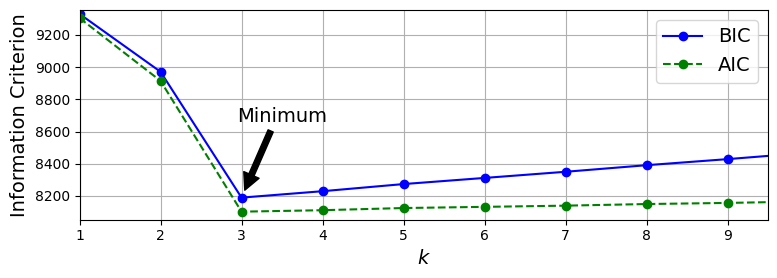

In [111]:
# extra code – this cell generates and saves Figure 9–20
# 클러스터 개수를 1~10까지 바꾸며 GMM 학습

gms_per_k = [GaussianMixture(n_components=k, n_init=10, random_state=42).fit(X)
             for k in range(1, 11)]

# 각각의 모델에 대해 BIC, AIC 계산
bics = [model.bic(X) for model in gms_per_k]
aics = [model.aic(X) for model in gms_per_k]

# 시각화
plt.figure(figsize=(8, 3))
plt.plot(range(1, 11), bics, "bo-", label="BIC")
plt.plot(range(1, 11), aics, "go--", label="AIC")
plt.xlabel("$k$")
plt.ylabel("Information Criterion")
plt.axis([1, 9.5, min(aics) - 50, max(aics) + 50])
plt.annotate("", xy=(3, bics[2]), xytext=(3.4, 8650),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.text(3.5, 8660, "Minimum", horizontalalignment="center")
plt.legend()
plt.grid()
save_fig("aic_bic_vs_k_plot")
plt.show()

## Bayesian Gaussian Mixture Models

Rather than manually searching for the optimal number of clusters, it is possible to use instead the `BayesianGaussianMixture` class which is capable of giving weights equal (or close) to zero to unnecessary clusters. Just set the number of components to a value that you believe is greater than the optimal number of clusters, and the algorithm will eliminate the unnecessary clusters automatically.

In [112]:
from sklearn.mixture import BayesianGaussianMixture
# 기존 GaussianMixture는 클러스터 개수(n_components)를 사전에 지정해야 함.
# Bayesian 불필요한 클러스터는 weight=0으로 설정하여 자동으로 제거.

# 클러스터 개수는 넉넉히 10개 설정
bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X)

# 각 클러스터의 weight 확인
# 0이면 해당 클러스터는 사용되지 않음
bgm.weights_.round(2)

/usr/local/lib/python3.11/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


array([0.4 , 0.21, 0.  , 0.4 , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ])

The algorithm automatically detected that only 3 components are needed!

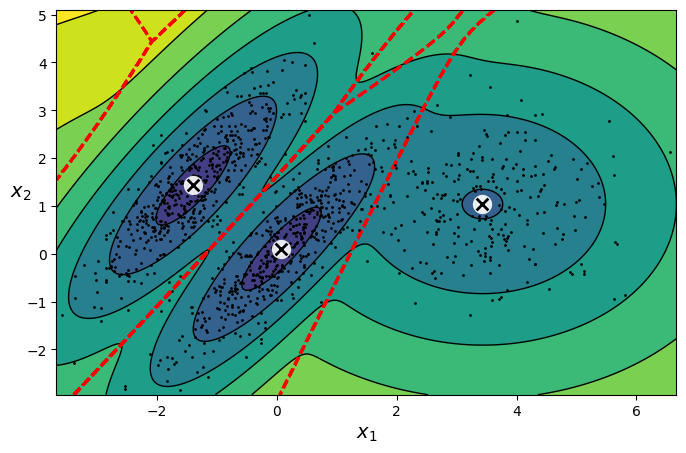

In [113]:
# extra code – this figure is almost identical to Figure 9–16
plt.figure(figsize=(8, 5))

# 이전에 정의한 contour 그리기 함수
plot_gaussian_mixture(bgm, X)
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


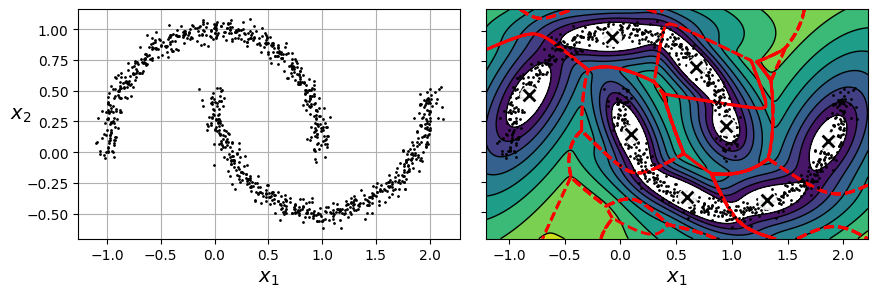

In [114]:
# extra code – this cell generates and saves Figure 9–21
# 복잡한 데이터셋 (moons)에서의 결과 확인
X_moons, y_moons = make_moons(n_samples=1000, noise=0.05, random_state=42)

bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X_moons)

plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_data(X_moons)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$", rotation=0)
plt.grid()

plt.subplot(122)
plot_gaussian_mixture(bgm, X_moons, show_ylabels=False)

# BayesianGaussianMixture는 여전히 타원형(ellipsoidal) 클러스터로 분리함
# 이론적으로는 밀도 근사에 유리하나, 비선형 구조 인식에는 한계 있음
# 결과적으로 8개의 클러스터로 분리하는 모습 보임
save_fig("moons_vs_bgm_plot")
plt.show()

Oops, not great... instead of detecting 2 moon-shaped clusters, the algorithm detected 8 ellipsoidal clusters. However, the density plot does not look too bad, so it might be usable for anomaly detection.

# Exercise solutions

## 1. to 9.

1. In Machine Learning, clustering is the unsupervised task of grouping similar instances together. The notion of similarity depends on the task at hand: for example, in some cases two nearby instances will be considered similar, while in others similar instances may be far apart as long as they belong to the same densely packed group. Popular clustering algorithms include K-Means, DBSCAN, agglomerative clustering, BIRCH, Mean-Shift, affinity propagation, and spectral :.
2. The main applications of clustering algorithms include data analysis, customer segmentation, recommender systems, search engines, image segmentation, semi-supervised learning, dimensionality reduction, anomaly detection, and novelty detection.
3. The elbow rule is a simple technique to select the number of clusters when using K-Means: just plot the inertia (the mean squared distance from each instance to its nearest centroid) as a function of the number of clusters, and find the point in the curve where the inertia stops dropping fast (the "elbow"). This is generally close to the optimal number of clusters. Another approach is to plot the silhouette score as a function of the number of clusters. There will often be a peak, and the optimal number of clusters is generally nearby. The silhouette score is the mean silhouette coefficient over all instances. This coefficient varies from +1 for instances that are well inside their cluster and far from other clusters, to –1 for instances that are very close to another cluster. You may also plot the silhouette diagrams and perform a more thorough analysis.
4. Labeling a dataset is costly and time-consuming. Therefore, it is common to have plenty of unlabeled instances, but few labeled instances. Label propagation is a technique that consists in copying some (or all) of the labels from the labeled instances to similar unlabeled instances. This can greatly extend the number of labeled instances, and thereby allow a supervised algorithm to reach better performance (this is a form of semi-supervised learning). One approach is to use a clustering algorithm such as K-Means on all the instances, then for each cluster find the most common label or the label of the most representative instance (i.e., the one closest to the centroid) and propagate it to the unlabeled instances in the same cluster.
5. K-Means and BIRCH scale well to large datasets. DBSCAN and Mean-Shift look for regions of high density.
6. Active learning is useful whenever you have plenty of unlabeled instances but labeling is costly. In this case (which is very common), rather than randomly selecting instances to label, it is often preferable to perform active learning, where human experts interact with the learning algorithm, providing labels for specific instances when the algorithm requests them. A common approach is uncertainty sampling (see the _Active Learning_ section in chapter 9).
7. Many people use the terms _anomaly detection_ and _novelty detection_ interchangeably, but they are not exactly the same. In anomaly detection, the algorithm is trained on a dataset that may contain outliers, and the goal is typically to identify these outliers (within the training set), as well as outliers among new instances. In novelty detection, the algorithm is trained on a dataset that is presumed to be "clean," and the objective is to detect novelties strictly among new instances. Some algorithms work best for anomaly detection (e.g., Isolation Forest), while others are better suited for novelty detection (e.g., one-class SVM).
8. A Gaussian mixture model (GMM) is a probabilistic model that assumes that the instances were generated from a mixture of several Gaussian distributions whose parameters are unknown. In other words, the assumption is that the data is grouped into a finite number of clusters, each with an ellipsoidal shape (but the clusters may have different ellipsoidal shapes, sizes, orientations, and densities), and we don't know which cluster each instance belongs to. This model is useful for density estimation, clustering, and anomaly detection.
9. One way to find the right number of clusters when using a Gaussian mixture model is to plot the Bayesian information criterion (BIC) or the Akaike information criterion (AIC) as a function of the number of clusters, then choose the number of clusters that minimizes the BIC or AIC. Another technique is to use a Bayesian Gaussian mixture model, which automatically selects the number of clusters.

## 10. Cluster the Olivetti Faces Dataset

*Exercise: The classic Olivetti faces dataset contains 400 grayscale 64 × 64–pixel images of faces. Each image is flattened to a 1D vector of size 4,096. 40 different people were photographed (10 times each), and the usual task is to train a model that can predict which person is represented in each picture. Load the dataset using the `sklearn.datasets.fetch_olivetti_faces()` function.*

In [115]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [116]:
print(olivetti.DESCR)

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

In [117]:
olivetti.target

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

*Exercise: Then split it into a training set, a validation set, and a test set (note that the dataset is already scaled between 0 and 1). Since the dataset is quite small, you probably want to use stratified sampling to ensure that there are the same number of images per person in each set.*

In [118]:
from sklearn.model_selection import StratifiedShuffleSplit

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=40, random_state=42)
train_valid_idx, test_idx = next(strat_split.split(olivetti.data,
                                                   olivetti.target))
X_train_valid = olivetti.data[train_valid_idx]
y_train_valid = olivetti.target[train_valid_idx]
X_test = olivetti.data[test_idx]
y_test = olivetti.target[test_idx]

strat_split = StratifiedShuffleSplit(n_splits=1, test_size=80, random_state=43)
train_idx, valid_idx = next(strat_split.split(X_train_valid, y_train_valid))
X_train = X_train_valid[train_idx]
y_train = y_train_valid[train_idx]
X_valid = X_train_valid[valid_idx]
y_valid = y_train_valid[valid_idx]

In [119]:
print(X_train.shape, y_train.shape)
print(X_valid.shape, y_valid.shape)
print(X_test.shape, y_test.shape)

(280, 4096) (280,)
(80, 4096) (80,)
(40, 4096) (40,)


To speed things up, we'll reduce the data's dimensionality using PCA:

In [120]:
from sklearn.decomposition import PCA

pca = PCA(0.99)
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

pca.n_components_

np.int64(199)

*Exercise: Next, cluster the images using K-Means, and ensure that you have a good number of clusters (using one of the techniques discussed in this chapter).*

In [121]:
from sklearn.cluster import KMeans

k_range = range(5, 150, 5)
kmeans_per_k = []
for k in k_range:
    print(f"k={k}")
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_train_pca)
    kmeans_per_k.append(kmeans)

k=5
k=10
k=15
k=20
k=25
k=30
k=35
k=40
k=45
k=50
k=55
k=60
k=65
k=70
k=75
k=80
k=85
k=90
k=95
k=100
k=105
k=110
k=115
k=120
k=125
k=130
k=135
k=140
k=145


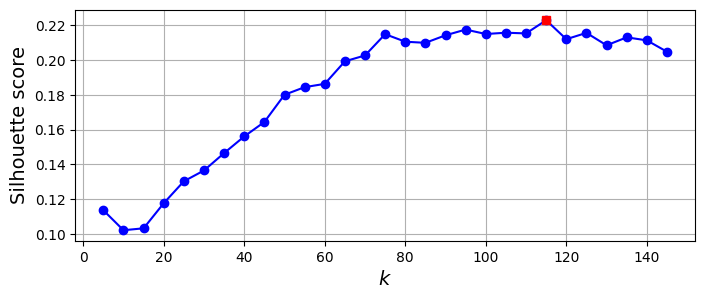

In [122]:
from sklearn.metrics import silhouette_score

silhouette_scores = [silhouette_score(X_train_pca, model.labels_)
                     for model in kmeans_per_k]
best_index = np.argmax(silhouette_scores)
best_k = k_range[best_index]
best_score = silhouette_scores[best_index]

plt.figure(figsize=(8, 3))
plt.plot(k_range, silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.plot(best_k, best_score, "rs")
plt.grid()
plt.show()

In [123]:
best_k

115

It looks like the best number of clusters is quite high, at 120. You might have expected it to be 40, since there are 40 different people on the pictures. However, the same person may look quite different on different pictures (e.g., with or without glasses, or simply shifted left or right).

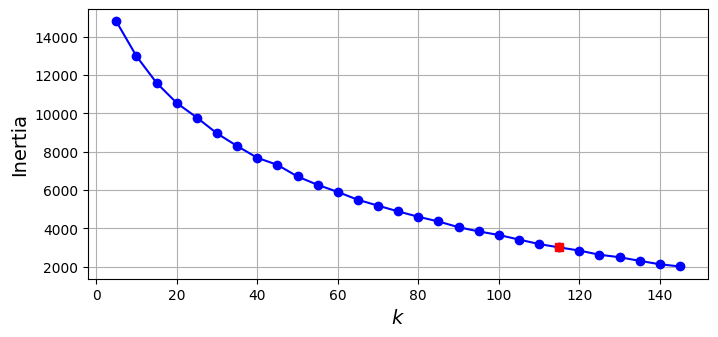

In [124]:
inertias = [model.inertia_ for model in kmeans_per_k]
best_inertia = inertias[best_index]

plt.figure(figsize=(8, 3.5))
plt.plot(k_range, inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.plot(best_k, best_inertia, "rs")
plt.grid()
plt.show()

The optimal number of clusters is not clear on this inertia diagram, as there is no obvious elbow, so let's stick with k=120.

In [125]:
best_model = kmeans_per_k[best_index]

*Exercise: Visualize the clusters: do you see similar faces in each cluster?*

Cluster 0


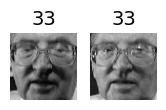

Cluster 1


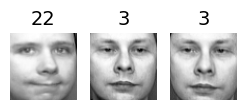

Cluster 2


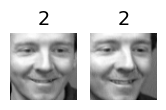

Cluster 3


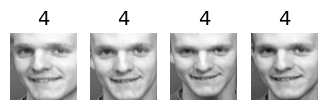

Cluster 4


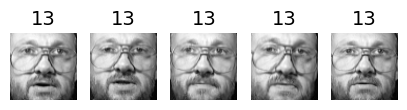

Cluster 5


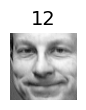

Cluster 6


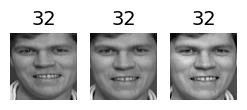

Cluster 7


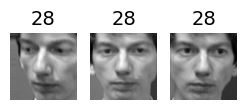

Cluster 8


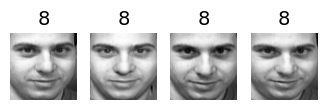

Cluster 9


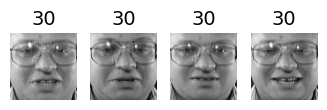

Cluster 10


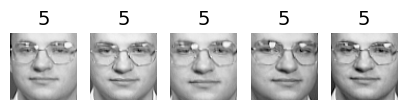

Cluster 11


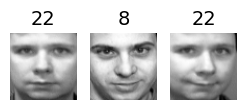

Cluster 12


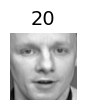

Cluster 13


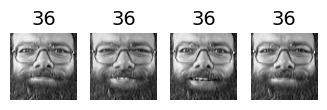

Cluster 14


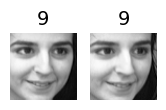

Cluster 15


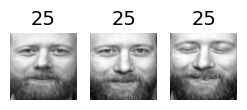

Cluster 16


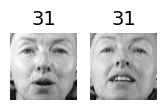

Cluster 17


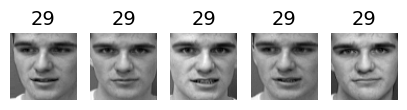

Cluster 18


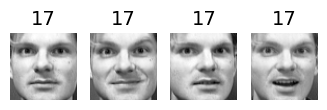

Cluster 19


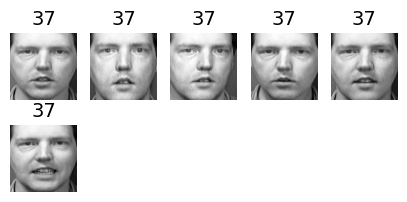

Cluster 20


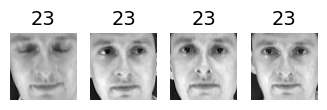

Cluster 21


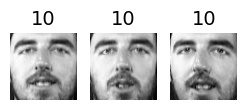

Cluster 22


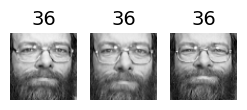

Cluster 23


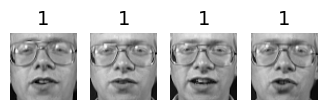

Cluster 24


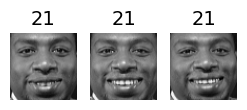

Cluster 25


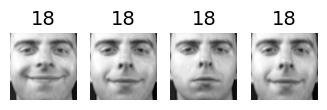

Cluster 26


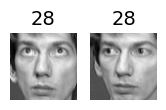

Cluster 27


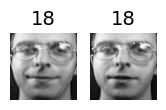

Cluster 28


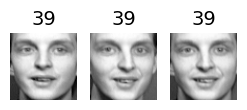

Cluster 29


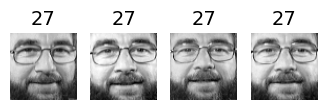

Cluster 30


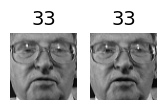

Cluster 31


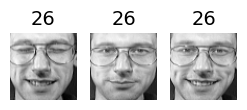

Cluster 32


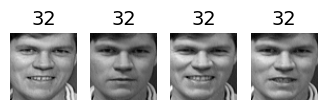

Cluster 33


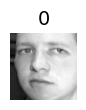

Cluster 34


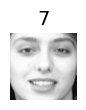

Cluster 35


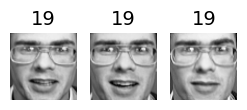

Cluster 36


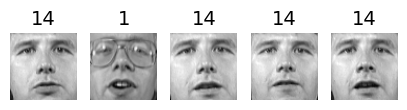

Cluster 37


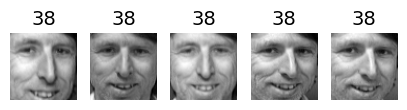

Cluster 38


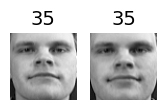

Cluster 39


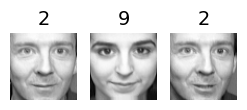

Cluster 40


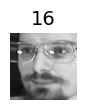

Cluster 41


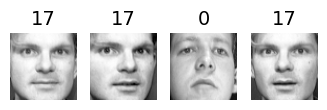

Cluster 42


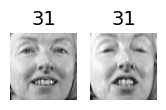

Cluster 43


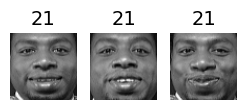

Cluster 44


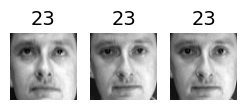

Cluster 45


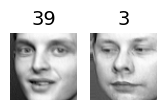

Cluster 46


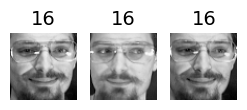

Cluster 47


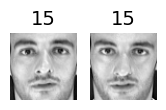

Cluster 48


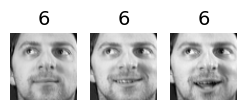

Cluster 49


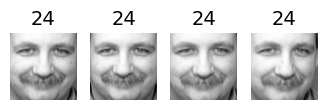

Cluster 50


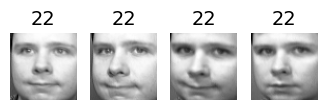

Cluster 51


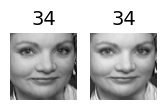

Cluster 52


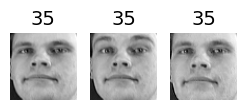

Cluster 53


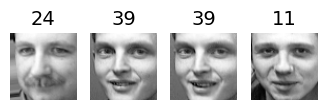

Cluster 54


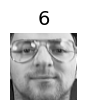

Cluster 55


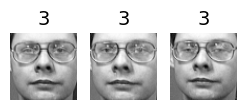

Cluster 56


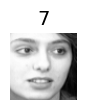

Cluster 57


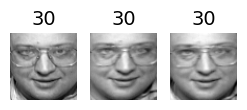

Cluster 58


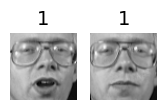

Cluster 59


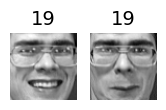

Cluster 60


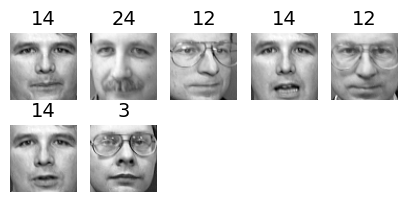

Cluster 61


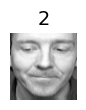

Cluster 62


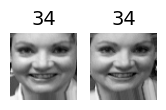

Cluster 63


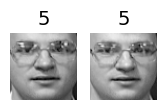

Cluster 64


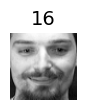

Cluster 65


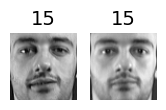

Cluster 66


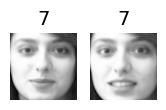

Cluster 67


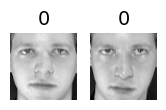

Cluster 68


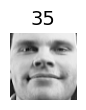

Cluster 69


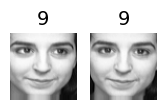

Cluster 70


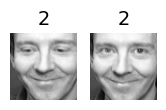

Cluster 71


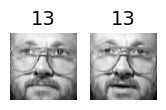

Cluster 72


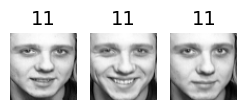

Cluster 73


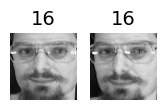

Cluster 74


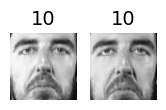

Cluster 75


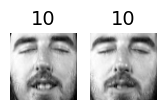

Cluster 76


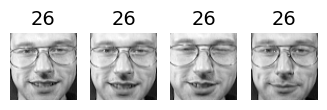

Cluster 77


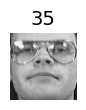

Cluster 78


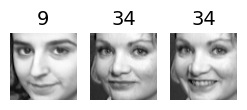

Cluster 79


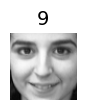

Cluster 80


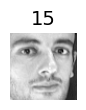

Cluster 81


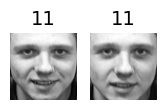

Cluster 82


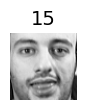

Cluster 83


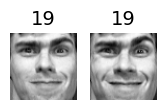

Cluster 84


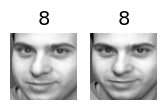

Cluster 85


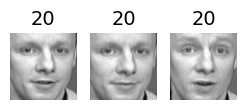

Cluster 86


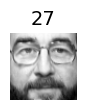

Cluster 87


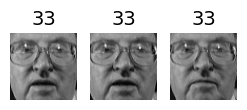

Cluster 88


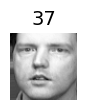

Cluster 89


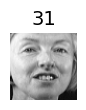

Cluster 90


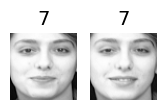

Cluster 91


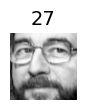

Cluster 92


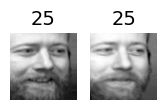

Cluster 93


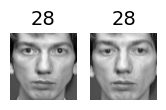

Cluster 94


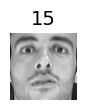

Cluster 95


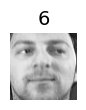

Cluster 96


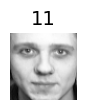

Cluster 97


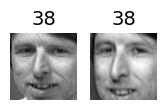

Cluster 98


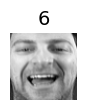

Cluster 99


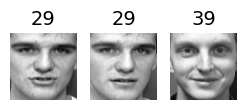

Cluster 100


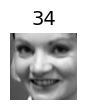

Cluster 101


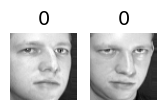

Cluster 102


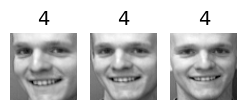

Cluster 103


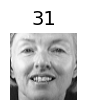

Cluster 104


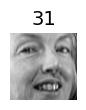

Cluster 105


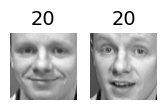

Cluster 106


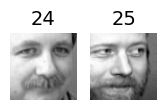

Cluster 107


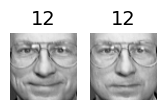

Cluster 108


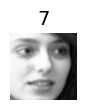

Cluster 109


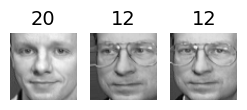

Cluster 110


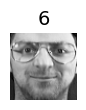

Cluster 111


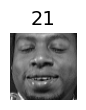

Cluster 112


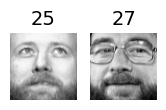

Cluster 113


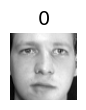

Cluster 114


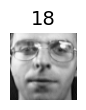

In [126]:
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

for cluster_id in np.unique(best_model.labels_):
    print("Cluster", cluster_id)
    in_cluster = best_model.labels_==cluster_id
    faces = X_train[in_cluster]
    labels = y_train[in_cluster]
    plot_faces(faces, labels)

About 2 out of 3 clusters are useful: that is, they contain at least 2 pictures, all of the same person. However, the rest of the clusters have either one or more intruders, or they have just a single picture.

Clustering images this way may be too imprecise to be directly useful when training a model (as we will see below), but it can be tremendously useful when labeling images in a new dataset: it will usually make labelling much faster.

## 11. Using Clustering as Preprocessing for Classification

*Exercise: Continuing with the Olivetti faces dataset, train a classifier to predict which person is represented in each picture, and evaluate it on the validation set.*

In [127]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_pca, y_train)
clf.score(X_valid_pca, y_valid)

0.9375

*Exercise: Next, use K-Means as a dimensionality reduction tool, and train a classifier on the reduced set.*

In [128]:
X_train_reduced = best_model.transform(X_train_pca)
X_valid_reduced = best_model.transform(X_valid_pca)
X_test_reduced = best_model.transform(X_test_pca)

clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_reduced, y_train)

clf.score(X_valid_reduced, y_valid)

0.7125

Yikes! That's not better at all! Let's see if tuning the number of clusters helps.

*Exercise: Search for the number of clusters that allows the classifier to get the best performance: what performance can you reach?*

We could use a `GridSearchCV` like we did earlier in this notebook, but since we already have a validation set, we don't need K-fold cross-validation, and we're only exploring a single hyperparameter, so it's simpler to just run a loop manually:

In [129]:
from sklearn.pipeline import make_pipeline

for n_clusters in k_range:
    pipeline = make_pipeline(
        KMeans(n_clusters=n_clusters, n_init=10, random_state=42),
        RandomForestClassifier(n_estimators=150, random_state=42)
    )
    pipeline.fit(X_train_pca, y_train)
    print(n_clusters, pipeline.score(X_valid_pca, y_valid))

5 0.3875
10 0.4875
15 0.5875
20 0.6125
25 0.6375
30 0.6125
35 0.7125
40 0.6875
45 0.7375
50 0.725
55 0.725
60 0.725
65 0.7
70 0.7125
75 0.7375
80 0.7625
85 0.7
90 0.75
95 0.75
100 0.75
105 0.7625
110 0.75
115 0.7125
120 0.7875
125 0.7625
130 0.75
135 0.7625
140 0.7125
145 0.725


Oh well, even by tuning the number of clusters, we never get beyond 80% accuracy. Looks like the distances to the cluster centroids are not as informative as the original images.

*Exercise: What if you append the features from the reduced set to the original features (again, searching for the best number of clusters)?*

In [130]:
X_train_extended = np.c_[X_train_pca, X_train_reduced]
X_valid_extended = np.c_[X_valid_pca, X_valid_reduced]
X_test_extended = np.c_[X_test_pca, X_test_reduced]

In [131]:
clf = RandomForestClassifier(n_estimators=150, random_state=42)
clf.fit(X_train_extended, y_train)
clf.score(X_valid_extended, y_valid)

0.8

That's a bit better, but still worse than without the cluster features. The clusters are not useful to directly train a classifier in this case (but they can still help when labelling new training instances).

## 12. A Gaussian Mixture Model for the Olivetti Faces Dataset

*Exercise: Train a Gaussian mixture model on the Olivetti faces dataset. To speed up the algorithm, you should probably reduce the dataset's dimensionality (e.g., use PCA, preserving 99% of the variance).*

In [132]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=40, random_state=42)
y_pred = gm.fit_predict(X_train_pca)

*Exercise: Use the model to generate some new faces (using the `sample()` method), and visualize them (if you used PCA, you will need to use its `inverse_transform()` method).*

In [133]:
n_gen_faces = 20
gen_faces_reduced, y_gen_faces = gm.sample(n_samples=n_gen_faces)
gen_faces = pca.inverse_transform(gen_faces_reduced)

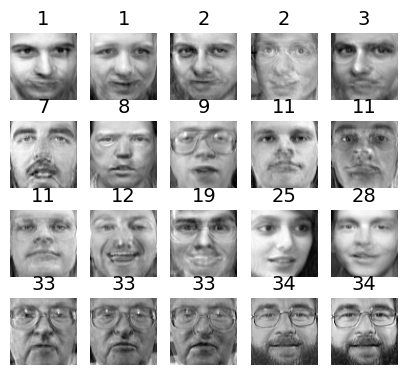

In [134]:
plot_faces(gen_faces, y_gen_faces)

*Exercise: Try to modify some images (e.g., rotate, flip, darken) and see if the model can detect the anomalies (i.e., compare the output of the `score_samples()` method for normal images and for anomalies).*

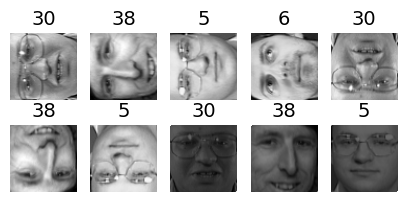

In [135]:
n_rotated = 4
rotated = np.transpose(X_train[:n_rotated].reshape(-1, 64, 64), axes=[0, 2, 1])
rotated = rotated.reshape(-1, 64*64)
y_rotated = y_train[:n_rotated]

n_flipped = 3
flipped = X_train[:n_flipped].reshape(-1, 64, 64)[:, ::-1]
flipped = flipped.reshape(-1, 64*64)
y_flipped = y_train[:n_flipped]

n_darkened = 3
darkened = X_train[:n_darkened].copy()
darkened[:, 1:-1] *= 0.3
y_darkened = y_train[:n_darkened]

X_bad_faces = np.r_[rotated, flipped, darkened]
y_bad = np.concatenate([y_rotated, y_flipped, y_darkened])

plot_faces(X_bad_faces, y_bad)

In [136]:
X_bad_faces_pca = pca.transform(X_bad_faces)

In [137]:
gm.score_samples(X_bad_faces_pca)

array([-1.85962675e+07, -1.73014142e+07, -4.15206562e+07, -4.81260067e+07,
       -3.20479238e+07, -1.35426895e+07, -2.92373970e+07, -9.25148489e+07,
       -1.03272225e+08, -5.41696236e+07])

The bad faces are all considered highly unlikely by the Gaussian Mixture model. Compare this to the scores of some training instances:

In [138]:
gm.score_samples(X_train_pca[:10])

array([1163.02020905, 1112.17308309, 1156.32132798, 1170.67602847,
       1073.69246356, 1139.89252815, 1113.7663003 , 1073.69245117,
       1048.17522985, 1048.17520868])

## 13. Using Dimensionality Reduction Techniques for Anomaly Detection

*Exercise: Some dimensionality reduction techniques can also be used for anomaly detection. For example, take the Olivetti faces dataset and reduce it with PCA, preserving 99% of the variance. Then compute the reconstruction error for each image. Next, take some of the modified images you built in the previous exercise, and look at their reconstruction error: notice how much larger the reconstruction error is. If you plot a reconstructed image, you will see why: it tries to reconstruct a normal face.*

We already reduced the dataset using PCA earlier:

In [139]:
X_train_pca.round(2)

array([[ -3.78,   1.85,  -5.14, ...,   0.14,  -0.21,   0.06],
       [-10.15,   1.53,  -0.77, ...,  -0.12,  -0.14,  -0.02],
       [ 10.02,  -2.88,  -0.92, ...,  -0.07,  -0.  ,   0.12],
       ...,
       [ -2.48,  -2.96,   1.3 , ...,   0.02,   0.03,  -0.15],
       [  3.22,  -5.35,   1.39, ...,  -0.06,  -0.23,   0.16],
       [  0.92,   3.65,   2.26, ...,  -0.14,  -0.07,   0.06]],
      dtype=float32)

In [140]:
def reconstruction_errors(pca, X):
    X_pca = pca.transform(X)
    X_reconstructed = pca.inverse_transform(X_pca)
    mse = np.square(X_reconstructed - X).mean(axis=-1)
    return mse

In [141]:
reconstruction_errors(pca, X_train).mean()

np.float32(0.00019205349)

In [142]:
reconstruction_errors(pca, X_bad_faces).mean()

np.float32(0.004707354)

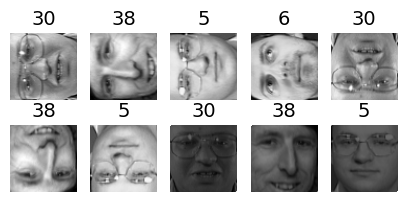

In [143]:
plot_faces(X_bad_faces, y_bad)

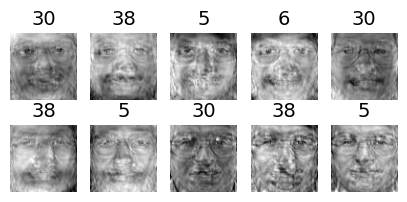

In [144]:
X_bad_faces_reconstructed = pca.inverse_transform(X_bad_faces_pca)
plot_faces(X_bad_faces_reconstructed, y_bad)